
## **Whether differences in average working hours are associated with variations in life satisfaction and mental health across countries.**

# **Hypothesis/Analysis Goal (Ask)**

Across countries, the average number of working hours differs widely due to cultural, economic and labor policy variations. An interesting question is whether these differences in working hours are related to variations in life satisfaction and mental health level among residents in different countries. Such descriptive analysis may help the government, employers and policy-makers to understand how work patterns influence well-being and provide strategies to enhance their employees’ work-life balance. In this context, we will examine the possible correlation between average annual working hours and national life satisfaction score, as well as mental health disorder prevalence, such as anxiety disorders and depression. The primary quality metric will be the correlation efficient, which quantifies the direction and magnitude of the association between working hours and life satisfaction. Additional descriptive statistics such as the mean, median and distribution of working hours and life satisfaction will be used to support data interpretation. Finally, subgroup comparisons may also be examined to evaluate whether patterns are consistent across different types of countries.


# **Data source identification and exploration (Prepare)**

**Requirement Analysis**: In order to address the question,it is necessary to collect multiple types of data that together provide a comprehensiv view of well-being and work patterns across countries.First, data on life satisfaction acros countries is required to serve as the primary outcome variable. In addition, information on the prevalence of mental health disorders in these countries is valuable to provide further context on population well-being. Finally, data on average annual working hours globally is needed to explore potential associations with well-being.

These three types of  dataset must be aligned with each other in terms of year and countries to allow meaningful comparisons and avoid inconsistencies. For robust analysis, it is desirable to have sufficient data over a long period, so that general trends in working hours and their potential relationship with well-being can be observed and assessed over time.


**List of considered sources**

We outline several sources we consider and explore to justify the final source selection.

* Annual Working Hours data:
[Annual Working Hours Per Worker](https://ourworldindata.org/grapher/annual-working-hours-per-worker)

[OECD Average Annual Hours Actually Worked Per Worker](https://data-explorer.oecd.org/vis?df[ds]=DisseminateFinalDMZ&df[id]=DSD_HW%40DF_AVG_ANN_HRS_WKD&df[ag]=OECD.ELS.SAE&df[vs]=1.0&dq=AUS%2BAUT%2BBEL%2BCAN%2BCHL%2BCOL%2BCRI%2BCZE%2BDNK%2BEST%2BFIN%2BFRA%2BDEU%2BGRC%2BHUN%2BISL%2BIRL%2BISR%2BITA%2BJPN%2BKOR%2BLVA%2BLTU%2BLUX%2BMEX%2BNLD%2BNZL%2BNOR%2BPOL%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BCHE%2BTUR%2BGBR%2BUSA%2BOECD........_T%2BICSE93_1....&pd=1990%2C2020&to[TIME_PERIOD]=false)


* Mental Illness Prevalence
[Mental Health](https://www.kaggle.com/datasets/imtkaggleteam/mental-health)

* World Life Happiness Index Report
[World Life Happiness](https://www.kaggle.com/datasets/usamabuttar/world-happiness-report-2005-present)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### DS1: *"Annual working hours per worker"* dataset by Our World in Data

**Description**: This dataset combines data from Huberman and Minns (2005) between 1870 and 1938 with the Penn World Table (1950 onward), containing information on the amount of working time per worker annually. It includes data from a wide range of countries over a long period of time from 1870 to 2023. By analysing this source, we can indicate the differences in working hours between countries and identify trends over a sufficiently long period, which can be combined with data on mental health for our analysis.

**The following code imports and displays few rows of the stored data:**

In [ ]:
# Attempt to load the CSV file
df_working_hours = pd.read_csv('/content/drive/MyDrive/data/annual-working-hours-per-worker.csv')
# Print the DataFrame to verify it loaded correctly
print(df_working_hours)

        Entity Code  Year  Working hours per worker
0      Albania  ALB  2005                   2343.90
1      Albania  ALB  2006                   2333.12
2      Albania  ALB  2007                   2334.51
3      Albania  ALB  2008                   2195.57
4      Albania  ALB  2009                   2191.19
...        ...  ...   ...                       ...
5058  Zimbabwe  ZWE  2019                   1903.71
5059  Zimbabwe  ZWE  2020                   1889.45
5060  Zimbabwe  ZWE  2021                   2011.57
5061  Zimbabwe  ZWE  2022                   2172.04
5062  Zimbabwe  ZWE  2023                   2311.02

[5063 rows x 4 columns]


**Overall information of the dataset:**

In [ ]:
df_working_hours.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5063 entries, 0 to 5062
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    5063 non-null   object 
 1   Code                      5063 non-null   object 
 2   Year                      5063 non-null   int64  
 3   Working hours per worker  5063 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 158.3+ KB


In [ ]:
df_working_hours.describe()

,Year,Working hours per worker
count,5063.000000,5063.000000
mean,1995.842188,2009.294312
std,23.819455,338.145010
min,1870.000000,1313.570000
25%,1982.000000,1746.360000
50%,2003.000000,1990.650000
75%,2014.000000,2243.820000
max,2023.000000,3483.000000


Looking at the sample dataset and data information, we can see that Entity (Country name), Code, Year and Working hours per worker are all stored in appropriate formats without any null values.

Each country with a respective year is stored as a single row in the dataset. Hence, we need to combine rows with similar country names to study the trend of changes in working hours over the period of time.

The **Entity** and **Year** columns are also sufficient to be combined with the data of mental health of a country in the same year, which can lead to meaningful analysis and comparisons in the future.

**Exploring the countries and years in the dataset:**

Get the names and number of countries provided:

In [ ]:
# Get the unique countries from the Entity columns
unique_countries= df_working_hours['Entity'].unique()

# Print the list of unique countries
print(unique_countries)

# Print the number of unique countries
print(str(len(unique_countries)) + ' countries')


['Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Belarus' 'Belgium' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso'
 'Cambodia' 'Cameroon' 'Canada' 'Chad' 'Chile' 'China' 'Colombia' 'Congo'
 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cyprus' 'Czechia'
 'Democratic Republic of Congo' 'Denmark' 'Dominican Republic' 'Ecuador'
 'Egypt' 'Estonia' 'Ethiopia' 'Finland' 'France' 'Gabon' 'Georgia'
 'Germany' 'Ghana' 'Greece' 'Guatemala' 'Hong Kong' 'Hungary' 'Iceland'
 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica'
 'Japan' 'Jordan' 'Kazakhstan' 'Kenya' 'Kuwait' 'Kyrgyzstan' 'Latvia'
 'Lebanon' 'Lithuania' 'Luxembourg' 'Madagascar' 'Malawi' 'Malaysia'
 'Mali' 'Malta' 'Mauritius' 'Mexico' 'Moldova' 'Morocco' 'Mozambique'
 'Myanmar' 'Namibia' 'Netherlands' 'New Zealand' 'Niger' 'Nigeria'
 'North Macedonia' 'Norway' 'Oman' 'Pakistan' 'Paraguay' 'Peru'
 'Philippines' 'Poland' 'Portu

Examine the number of years (data rows) each country has in the dataset:

In [ ]:
#Get the number of years each country has:
country_counts = df_working_hours.groupby('Entity')['Entity'].count().sort_values(ascending=False)
print("Number of years per country:")
print(country_counts)


Number of years per country:
Entity
Belgium          81
Australia        81
United States    81
Sweden           81
Denmark          81
                 ..
Turkmenistan     19
Zimbabwe         19
Sudan            18
Kyrgyzstan       17
Syria            16
Name: Entity, Length: 130, dtype: int64


From the output above, we can see that the dataset provides a sufficient number of 130 countries from different geographical regions and economical status for analysis. However, each country has a different number of years collected. This is because some countries have available data since 1870, while others only have available data since 2000, narrowing the time period we can use to compare between countries

Get the year span of the dataset:

In [ ]:
np.unique(df_working_hours['Year'])

array([1870, 1880, 1890, 1900, 1913, 1929, 1938, 1950, 1951, 1952, 1953,
       1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964,
       1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
       1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997,
       1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023])

Examine the number of countries (data rows) each year has in the dataset:

In [ ]:
#Get the number of countries each year has:
year_counts = df_working_hours.groupby('Year')['Year'].count().sort_values(ascending=False)
print("Number of countries per year:")
print(year_counts)


Number of countries per year:
Year
2008    130
2013    130
2005    130
2006    130
2012    130
       ... 
1900     14
1938     14
1929     14
1870     14
1890     14
Name: Year, Length: 81, dtype: int64


The **Year** data spans around 150 years from 1870 to 2013, but older years have less data (less number of countries collected). Hence, we need to carefully choose time periods to analyze in order to avoid bias and outliers.

**Exploring annual working hours between different countries and years:**

Working hours of counties with the most and least years collected:

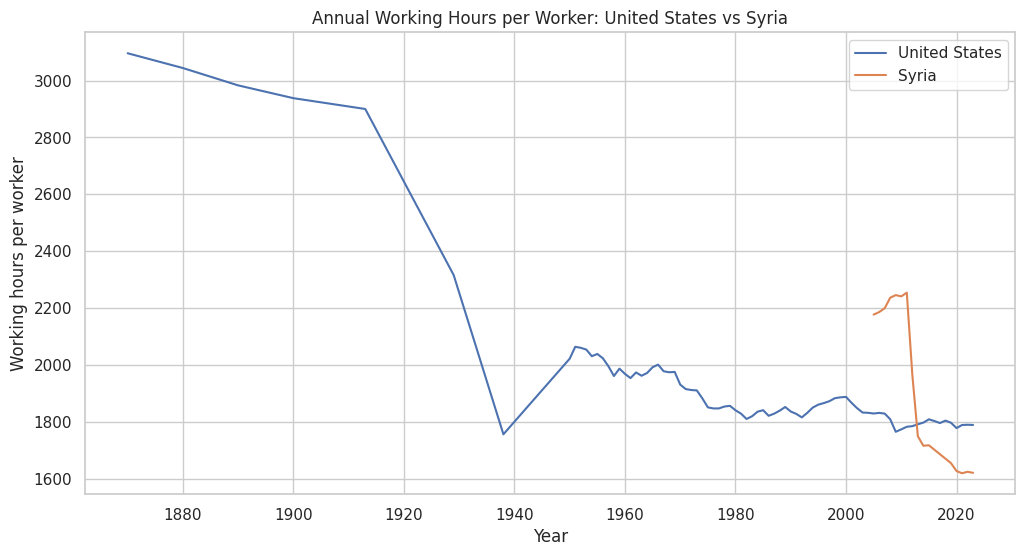

In [ ]:
# Select countries with 81 years and 16 years of data
country_81_years = 'United States'
country_16_years = 'Syria'

# Filter data for the selected countries
df_us = df_working_hours[df_working_hours['Entity'] == country_81_years]
df_syria = df_working_hours[df_working_hours['Entity'] == country_16_years]

# Create the plot
plt.figure(figsize=(12, 6))

plt.plot(df_us['Year'], df_us['Working hours per worker'], label=country_81_years)
plt.plot(df_syria['Year'], df_syria['Working hours per worker'], label=country_16_years)

plt.xlabel('Year')
plt.ylabel('Working hours per worker')
plt.title('Annual Working Hours per Worker: United States vs Syria')
plt.legend()
plt.grid(True)
plt.show()

For the U.S., the dataset spans a very long historical period (late 1800s to 2020s), but for Syria, the dataset covers a much shorter and more recent time range. This stems from the fact that the dataset is compiled from different historical sources and may have data availability limitations for some countries. This suggests that analyzing trends may be limited to some countries, and cross-country comparison can be done in a limited time period.

The country with the least number of years observed (Syria) has it first observation in the 2000s. Hence, we try fixing the time period starting from 2005 for cross-country comparisons. The following code plots working hours of a random 30 countries from 2005:

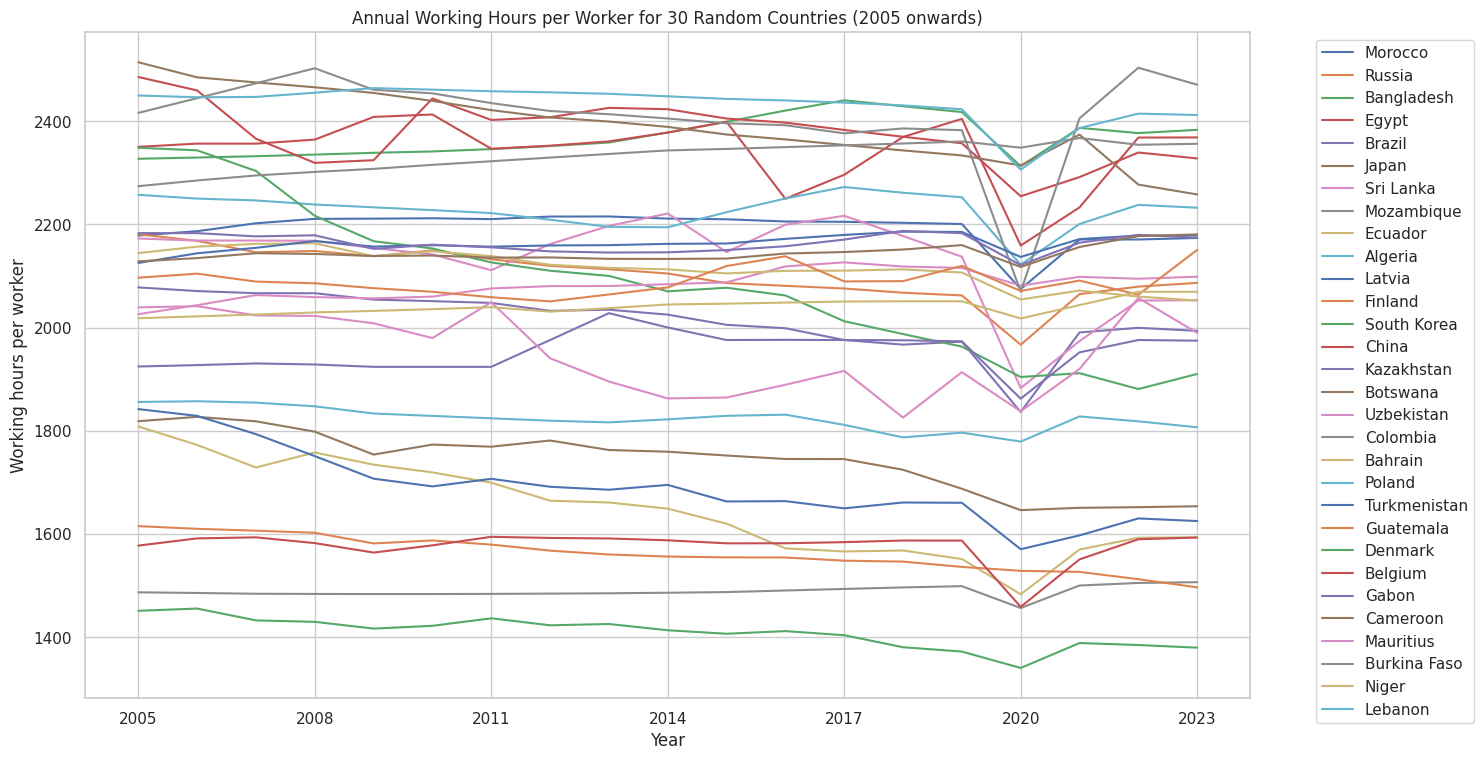

In [ ]:
# Filter data for years 2005 and later
df_2005_onwards = df_working_hours[df_working_hours['Year'] >= 2005]

# Get unique countries from the filtered data
countries_2005_onwards = df_2005_onwards['Entity'].unique()

# Randomly select 30 countries
num_countries_to_plot = 30
if len(countries_2005_onwards) < num_countries_to_plot:
    num_countries_to_plot = len(countries_2005_onwards)
selected_countries = np.random.choice(countries_2005_onwards, num_countries_to_plot, replace=False)

# Filter the DataFrame for the selected countries
df_selected_countries = df_2005_onwards[df_2005_onwards['Entity'].isin(selected_countries)]

# Create the plot
plt.figure(figsize=(15, 8))
for country in selected_countries:
    df_country = df_selected_countries[df_selected_countries['Entity'] == country].sort_values(by='Year') # Sort by Year to prevent self-intersections
    plt.plot(df_country['Year'], df_country['Working hours per worker'], label=country)

plt.xlabel('Year')
plt.ylabel('Working hours per worker')
plt.title(f'Annual Working Hours per Worker for {num_countries_to_plot} Random Countries (2005 onwards)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot area
plt.grid(True)

# Ensure x-axis ticks are integers
plt.xticks(np.arange(df_2005_onwards['Year'].min(), df_2005_onwards['Year'].max()+1, 3)) # Adjust step as needed, e.g., 3 years

plt.tight_layout()
plt.show()

The dataset is a balanced multi-country panel, recording annual working hours per worker for multiple countries over a common time period (2005–2023), enabling both temporal and cross-country comparisons. It shows substantial and persistent variation across countries, indicating structural differences in labor markets rather than random fluctuations.

The synchronized decline around 2020 suggests the dataset is sensitive to global shocks, supporting its reliability in capturing real-world disruptions.

Fixing one year (2015) to identify countries with highest and lowest working hours:





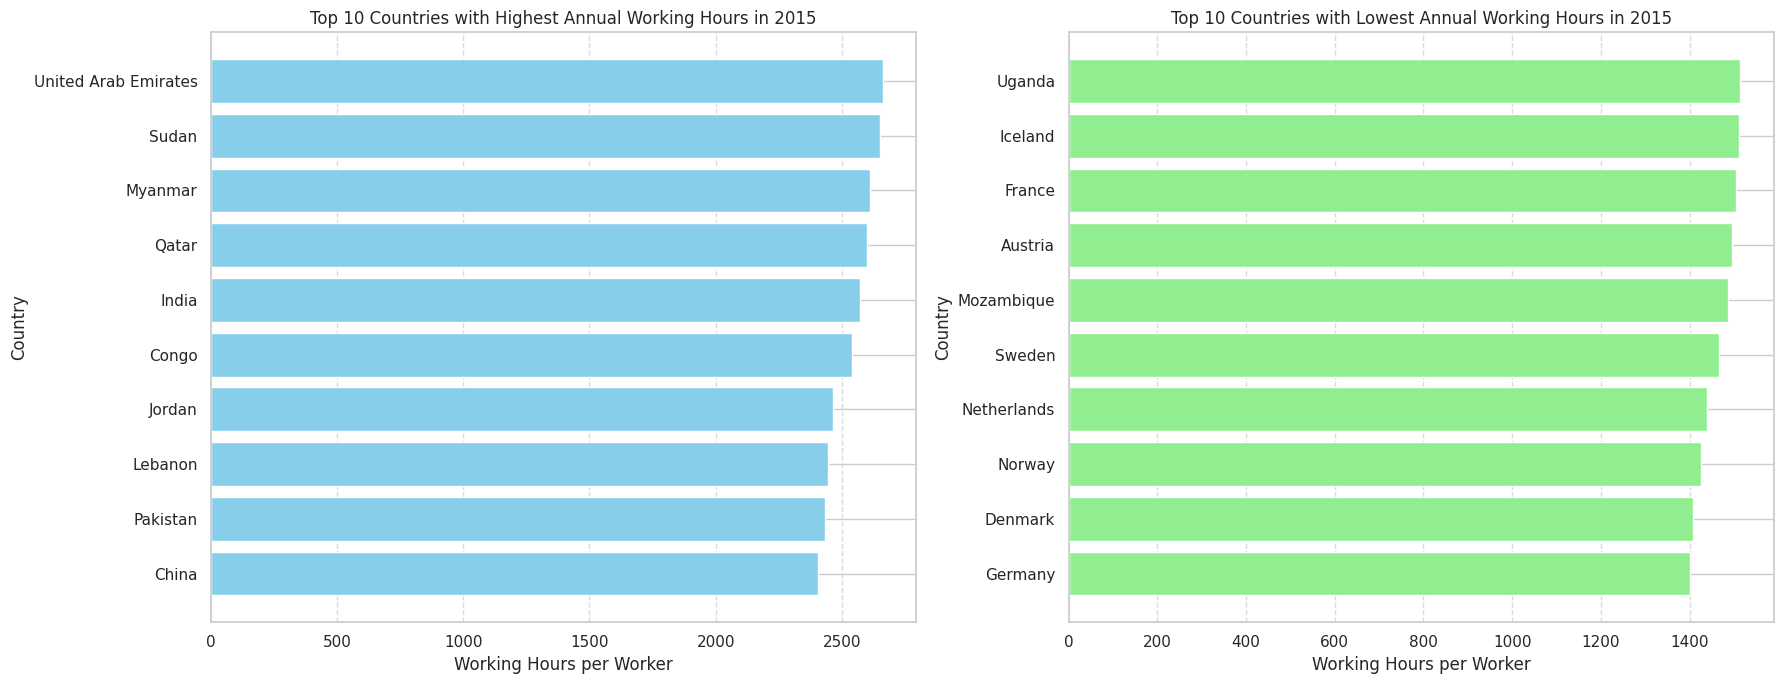

In [ ]:
# Filter data for the year 2015
df_2015 = df_working_hours[df_working_hours['Year'] == 2015]

# Sort by 'Working hours per worker' to get top and bottom countries
df_2015_sorted = df_2015.sort_values(by='Working hours per worker', ascending=False)

# Get top 10 countries with highest working hours
top_10_highest = df_2015_sorted.head(10)

# Get bottom 10 countries with lowest working hours
top_10_lowest = df_2015_sorted.tail(10)

# Create the plots
plt.figure(figsize=(18, 7))

# Bar chart for Top 10 Highest Working Hours
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.barh(top_10_highest['Entity'], top_10_highest['Working hours per worker'], color='skyblue') # Changed color to 'blue'
plt.gca().invert_yaxis() # Invert y-axis to have the highest value at the top
plt.title('Top 10 Countries with Highest Annual Working Hours in 2015')
plt.xlabel('Working Hours per Worker')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Bar chart for Top 10 Lowest Working Hours
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.barh(top_10_lowest['Entity'], top_10_lowest['Working hours per worker'], color='lightgreen') # Changed color to 'green'
plt.gca().invert_yaxis() # Invert y-axis to have the lowest value at the top
plt.title('Top 10 Countries with Lowest Annual Working Hours in 2015')
plt.xlabel('Working Hours per Worker')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Looking at the charts, we can see large cross-country variation in annual working hours in 2015. The highest-hour countries work almost twice as many hours as the lowest-hour countries. This indicates systematic differences in labor structures across countries.

Developing countries such as Uganda and Mozambique stayed among the developed ones like France and Germany in the top countries with lowest working hours, suggesting the complication in examining the trends between countries.

**Data quality considerations**

We highlight the following quality criteria to determine the suitability of the dataset for our task:

- Completeness:
The dataset satisfies our requirements in terms of completeness, as it provides annual working hours per worker for a wide range of countries over long time horizons. Coverage is particularly strong for developed economies, with consistent yearly observations that allow meaningful trend and cross-country analysis.

- Interpretability:
The interpretability of the dataset is high. It focuses on a small number of well-defined attributes (country, year, and annual working hours per worker) with clear semantics.

- Source reputation and provenance:
The dataset is published by Our World in Data, a well-established and reputable data provider in the academic and data science communities. The data is based on research from Huberman and Minns (2005) between 1870 and 1938 with the Penn World Table (1950 onward).

**Some limitations**

- Data collection methodology may vary by countries, years and sources, which may lead to heterogenity in measurement (i.e. Developed countries have more than 80 years recorded but developing ones may have only 20)

- Historical values, especially for earlier years, may rely partly on estimates or reconstructions, which could impact precision.

**Conclusion**

Despite potential differences in data collection methodologies across countries, the dataset aligns well with our analytical goals, and we therefore opted to use it. We remain aware that such inconsistencies may introduce measurement noise into the analysis.

### DS2: *"Average annual hours actually worked per worker"* dataset by OECD Data Explorer

**Description:** This dataset, published by the OECD through its Data Explorer, provides annual data on the average number of hours actually worked per worker across countries. It captures realised working time rather than contractual or standard hours, accounting for factors such as overtime, part-time work, and absences. The dataset is disaggregated by multiple dimensions, including sex, age group, labour force status, working time arrangement, and job coverage, allowing for detailed cross-country and demographic comparisons of labour input over time.

Load dataset and display 5 first observations

In [ ]:
# Attempt to load the CSV file
df_work_hours = pd.read_csv('/content/drive/MyDrive/data/oecd-working-hour.csv')


In [ ]:
# Get the column labels (header)
column_labels = df_work_hours.columns.tolist()

# Print the column labels
print(column_labels)

['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA', 'Reference area', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure', 'SEX', 'Sex', 'AGE', 'Age', 'LABOUR_FORCE_STATUS', 'Labour force status', 'WORK_PERIOD', 'Work period', 'HOURS_TYPE', 'Hours type', 'WORKER_STATUS', 'Worker status', 'WORK_TIME_ARNGMNT', 'Working time arrangement', 'AGGREGATION_OPERATION', 'Aggregation operation', 'HOUR_BANDS', 'Hour bands', 'JOB_COVERAGE', 'Job coverage', 'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value', 'OBS_STATUS', 'Observation status', 'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'Decimals']


In [ ]:
df_work_hours.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,MEASURE,Measure,UNIT_MEASURE,Unit of measure,...,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
0,DATAFLOW,OECD.ELS.SAE:DSD_HW@DF_AVG_ANN_HRS_WKD(1.0),Average annual hours actually worked per worker,I,SWE,Sweden,HW,Hours worked,H_Y_PS,Hours per year per person,...,1950,NaN,1820.795,NaN,A,Normal value,NaN,NaN,0,Zero
1,DATAFLOW,OECD.ELS.SAE:DSD_HW@DF_AVG_ANN_HRS_WKD(1.0),Average annual hours actually worked per worker,I,SWE,Sweden,HW,Hours worked,H_Y_PS,Hours per year per person,...,1951,NaN,1812.666,NaN,A,Normal value,NaN,NaN,0,Zero
2,DATAFLOW,OECD.ELS.SAE:DSD_HW@DF_AVG_ANN_HRS_WKD(1.0),Average annual hours actually worked per worker,I,SWE,Sweden,HW,Hours worked,H_Y_PS,Hours per year per person,...,1952,NaN,1812.666,NaN,A,Normal value,NaN,NaN,0,Zero
3,DATAFLOW,OECD.ELS.SAE:DSD_HW@DF_AVG_ANN_HRS_WKD(1.0),Average annual hours actually worked per worker,I,SWE,Sweden,HW,Hours worked,H_Y_PS,Hours per year per person,...,1953,NaN,1794.603,NaN,A,Normal value,NaN,NaN,0,Zero
4,DATAFLOW,OECD.ELS.SAE:DSD_HW@DF_AVG_ANN_HRS_WKD(1.0),Average annual hours actually worked per worker,I,SWE,Sweden,HW,Hours worked,H_Y_PS,Hours per year per person,...,1954,NaN,1804.538,NaN,A,Normal value,NaN,NaN,0,Zero


This data includes many columns

Data set information and description

In [ ]:
df_work_hours.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3696 entries, 0 to 3695
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   STRUCTURE                 3696 non-null   object 
 1   STRUCTURE_ID              3696 non-null   object 
 2   STRUCTURE_NAME            3696 non-null   object 
 3   ACTION                    3696 non-null   object 
 4   REF_AREA                  3696 non-null   object 
 5   Reference area            3696 non-null   object 
 6   MEASURE                   3696 non-null   object 
 7   Measure                   3696 non-null   object 
 8   UNIT_MEASURE              3696 non-null   object 
 9   Unit of measure           3696 non-null   object 
 10  SEX                       3696 non-null   object 
 11  Sex                       3696 non-null   object 
 12  AGE                       3696 non-null   object 
 13  Age                       3696 non-null   object 
 14  LABOUR_F

The dataset is largely complete, with most variables having no missing values across all 3,696 observations. However, several columns contain 100% missing values, including Time period (label column), Observation value (label column), Unit multiplier, and Unit of measure (multiplier). These appear to be metadata or duplicated label fields rather than core variables.

In [ ]:
df_work_hours.describe()

,TIME_PERIOD,Time period,OBS_VALUE,Observation value,UNIT_MULT,Unit multiplier,DECIMALS
count,3696.000000,0.0,3696.000000,0.0,0.0,0.0,3696.0
mean,2001.113366,NaN,1759.774596,NaN,NaN,NaN,0.0
std,16.118871,NaN,243.680084,NaN,NaN,NaN,0.0
min,1950.000000,NaN,1207.347000,NaN,NaN,NaN,0.0
25%,1992.000000,NaN,1588.262500,NaN,NaN,NaN,0.0
50%,2004.000000,NaN,1745.108500,NaN,NaN,NaN,0.0
75%,2014.000000,NaN,1885.777000,NaN,NaN,NaN,0.0
max,2024.000000,NaN,2603.340000,NaN,NaN,NaN,0.0


In [ ]:
# Select relevant columns:
df_hours_select = df_work_hours[['REF_AREA', 'Reference area', 'TIME_PERIOD', 'Worker status', 'OBS_VALUE']]
# Print the selected DataFrame to verify it loaded correctly
print(df_hours_select)

     REF_AREA Reference area  TIME_PERIOD Worker status  OBS_VALUE
0         SWE         Sweden         1950         Total   1820.795
1         SWE         Sweden         1951         Total   1812.666
2         SWE         Sweden         1952         Total   1812.666
3         SWE         Sweden         1953         Total   1794.603
4         SWE         Sweden         1954         Total   1804.538
...       ...            ...          ...           ...        ...
3691      MLT          Malta         1998         Total   2164.000
3692      MLT          Malta         1999         Total   2183.000
3693      MLT          Malta         2005         Total   2167.000
3694      MLT          Malta         2006         Total   2175.000
3695      MLT          Malta         2007         Total   2171.000

[3696 rows x 5 columns]


**Compare 'Total' vs. 'Employees' Working Hours in some specific countries**

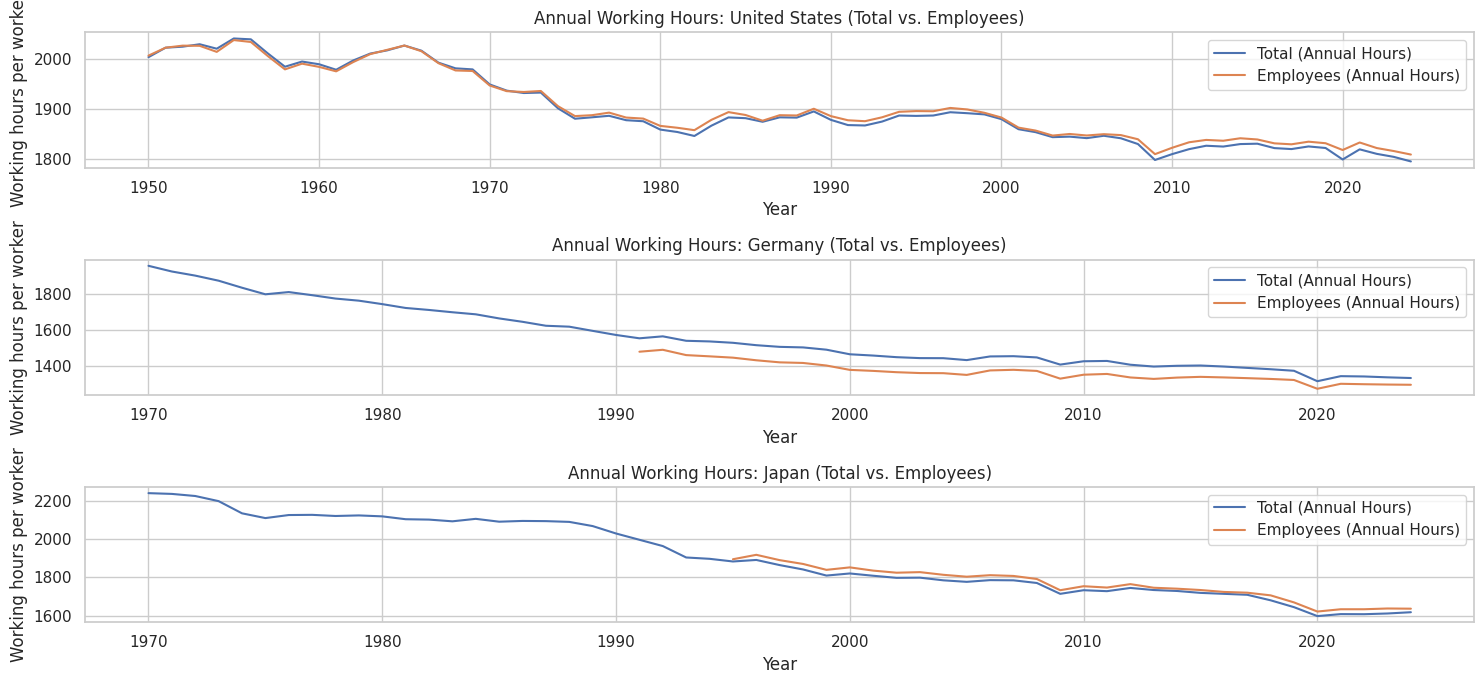

In [ ]:
# Filter for 'Total' and 'Employees' worker status
df_filtered_status = df_hours_select[df_hours_select['Worker status'].isin(['Total', 'Employees'])]

# Get a list of countries that have both 'Total' and 'Employees' data
countries_with_both_status = df_filtered_status.groupby('Reference area')['Worker status'].nunique()
countries_to_plot = countries_with_both_status[countries_with_both_status == 2].index.tolist()

# Select a few countries for demonstration
selected_countries_for_comparison = ['United States', 'Germany', 'Japan']

plt.figure(figsize=(15, 7))

for country in selected_countries_for_comparison:
    df_country = df_filtered_status[df_filtered_status['Reference area'] == country].sort_values(by='TIME_PERIOD')

    plt.subplot(len(selected_countries_for_comparison), 1, selected_countries_for_comparison.index(country) + 1)

    for status in ['Total', 'Employees']:
        df_status = df_country[df_country['Worker status'] == status]
        plt.plot(df_status['TIME_PERIOD'], df_status['OBS_VALUE'], label=f'{status} (Annual Hours)')

    plt.title(f'Annual Working Hours: {country} (Total vs. Employees)')
    plt.xlabel('Year')
    plt.ylabel('Working hours per worker')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

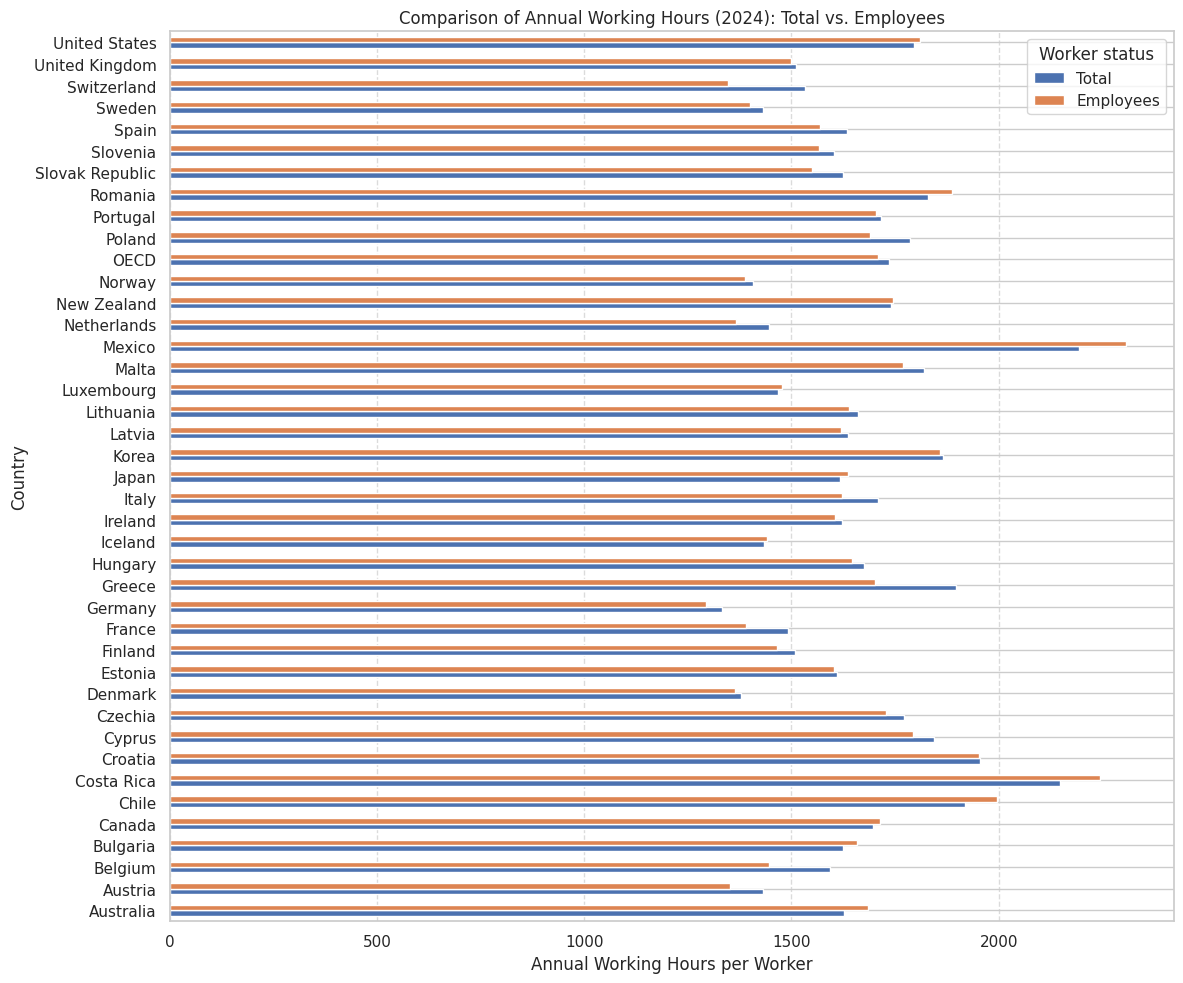

In [ ]:
# Select a recent year for comparison, e.g., 2020 (or max available year)
latest_year = df_filtered_status['TIME_PERIOD'].max()
df_latest_year = df_filtered_status[df_filtered_status['TIME_PERIOD'] == latest_year]

# Pivot the table to have 'Total' and 'Employees' as columns
df_pivot = df_latest_year.pivot_table(index='Reference area', columns='Worker status', values='OBS_VALUE')

# Drop rows where either 'Total' or 'Employees' data is missing
df_pivot = df_pivot.dropna(subset=['Total', 'Employees'])

# Create a bar chart for comparison
plt.figure(figsize=(12, 10))
df_pivot[['Total', 'Employees']].plot(kind='barh', figsize=(12, 10))
plt.title(f'Comparison of Annual Working Hours ({latest_year}): Total vs. Employees')
plt.xlabel('Annual Working Hours per Worker')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The dataset provides a comprehensive view of working hours across the whole population by distinguishing between employees and total workers. This method is inclusive because it counts towards those who are self-employed or are unpaid family workers.

In addition, the dataset is of good quality and suitable for analysis, showing consistent long-term trends and a stable, meaningful difference between total workers and employees, as well as clear variation across countries.



Filter data to total

In [ ]:
df_total_status = df_hours_select[df_hours_select['Worker status'] == 'Total']
print(df_total_status)

     REF_AREA Reference area  TIME_PERIOD Worker status  OBS_VALUE
0         SWE         Sweden         1950         Total   1820.795
1         SWE         Sweden         1951         Total   1812.666
2         SWE         Sweden         1952         Total   1812.666
3         SWE         Sweden         1953         Total   1794.603
4         SWE         Sweden         1954         Total   1804.538
...       ...            ...          ...           ...        ...
3691      MLT          Malta         1998         Total   2164.000
3692      MLT          Malta         1999         Total   2183.000
3693      MLT          Malta         2005         Total   2167.000
3694      MLT          Malta         2006         Total   2175.000
3695      MLT          Malta         2007         Total   2171.000

[2071 rows x 5 columns]


In [ ]:
# Get the unique countries from the Entity columns
unique_countries= df_total_status['Reference area'].unique()

# Print the list of unique countries
print(unique_countries)

# Print the number of unique countries
print(str(len(unique_countries)) + ' countries')

['Sweden' 'United States' 'Finland' 'Australia' 'Austria' 'Belgium'
 'Canada' 'Chile' 'Colombia' 'Costa Rica' 'Czechia' 'Denmark' 'Estonia'
 'France' 'Germany' 'Greece' 'Hungary' 'Iceland' 'Ireland' 'Israel'
 'Italy' 'Japan' 'Korea' 'Latvia' 'Lithuania' 'Luxembourg' 'Mexico'
 'Netherlands' 'New Zealand' 'Norway' 'Poland' 'Portugal'
 'Slovak Republic' 'Slovenia' 'Spain' 'Switzerland' 'Türkiye'
 'United Kingdom' 'OECD' 'Bulgaria' 'Croatia' 'Cyprus' 'Malta' 'Peru'
 'Romania' 'Russia']
46 countries


In [ ]:
country_counts = df_total_status.groupby('Reference area')['Reference area'].count().sort_values(ascending=False)
print("Number of years per country:")
print(country_counts)


Number of years per country:
Reference area
United States      75
France             75
Sweden             75
Finland            65
Canada             64
Norway             63
Iceland            55
Ireland            55
Germany            55
Italy              55
Denmark            55
Belgium            55
OECD               55
Portugal           55
New Zealand        55
Netherlands        55
United Kingdom     55
Spain              55
Luxembourg         55
Japan              55
Colombia           54
Türkiye            52
Australia          46
Hungary            45
Israel             44
Greece             42
Chile              39
Costa Rica         38
Mexico             34
Switzerland        34
Poland             32
Czechia            32
Slovak Republic    30
Bulgaria           30
Austria            30
Cyprus             30
Croatia            30
Latvia             30
Slovenia           30
Malta              30
Lithuania          30
Romania            30
Russia             29
Estonia   

In [ ]:
#
year_counts = df_total_status.groupby('TIME_PERIOD')['TIME_PERIOD'].count().sort_values(ascending=False)
print("Number of countries per year:")
print(year_counts)


Number of countries per year:
TIME_PERIOD
2015    46
2014    46
2013    46
2016    46
2011    46
        ..
1956     3
1954     3
1955     3
1953     3
1952     3
Name: TIME_PERIOD, Length: 75, dtype: int64


The dataset covers a small range of countries over a long time span. It exhibits consistent long-term trends and stable, meaningful differences between total workers and employees, making it reliable for cross-country and temporal comparisons.

Compare working hours between US and Korea overtime

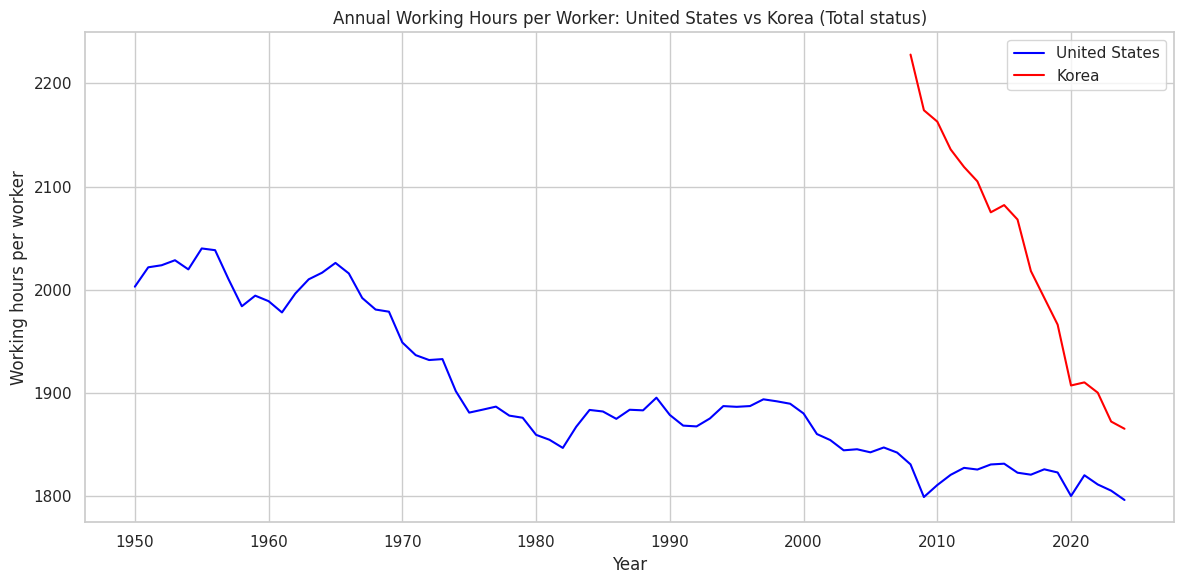

In [ ]:
# Select countries with most and least years of data from df_total_status
country_most_years = 'United States'
country_least_years = 'Korea'

# Filter data for the selected countries
df_us_total = df_total_status[df_total_status['Reference area'] == country_most_years].sort_values(by='TIME_PERIOD')
df_korea_total = df_total_status[df_total_status['Reference area'] == country_least_years].sort_values(by='TIME_PERIOD')

# Create the plot on a single graph
plt.figure(figsize=(12, 6))

plt.plot(df_us_total['TIME_PERIOD'], df_us_total['OBS_VALUE'], label=country_most_years, color='blue')
plt.plot(df_korea_total['TIME_PERIOD'], df_korea_total['OBS_VALUE'], label=country_least_years, color='red')

plt.xlabel('Year')
plt.ylabel('Working hours per worker')
plt.title(f'Annual Working Hours per Worker: {country_most_years} vs {country_least_years} (Total status)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Summary:**


*   Coverage: The dataset spans a long time period, allowing analysis of long-term trends in annual working hours. The data also provides a comprehensive view of working hours among total workers and only employees.

*   The number of observations is sufficient to support temporal analysis.

*   Data quality: Core variables (e.g., annual hours worked and time period) are complete.

*   Interpretability: Key variables such as working hours, worker status, and time period are clear and intuitive, making results easy to interpret.

**Limitation:**


*   Country coverage: The dataset includes relatively few countries, which limits its representativeness for global comparisons.


*   Variable redundancy: The dataset contains many columns, including duplicated labels and metadata with missing values, increasing preprocessing effort and the risk of confusion if not handled carefully.



### DS3 - Mental Illness Prevalence


**Description**: The kaggle dataset contains information on common mental health conditions that hundreds of millions suffer from them yearly, and many more do over their lifetimes. It provides country-level data on mental health disorder prevalence throughout a long period from 1990 to 2019, enabling longtitudal analysis across a large set of countries. In particular, the prevalence of depressive disorders and anxiety disorders offer relevant and informative indicators for our analysis, as these conditions are closely related to overal well-being and life satisfaction.

Save data and show 5 first rows in dataset.

In [ ]:
file_path = "/content/drive/MyDrive/data/mental-illness.csv"
mental_health_data = pd.read_csv(file_path)
mental_health_data.head()


,Entity,Code,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815


Overall information and description about dataset

In [ ]:
mental_health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6420 entries, 0 to 6419
Data columns (total 8 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Entity                                                                             6420 non-null   object 
 1   Code                                                                               6150 non-null   object 
 2   Year                                                                               6420 non-null   int64  
 3   Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized  6420 non-null   float64
 4   Depressive disorders (share of population) - Sex: Both - Age: Age-standardized     6420 non-null   float64
 5   Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized        6420 non-null   float6

From the data description, we observe that missing values only occur in column **Code**. This column contains country code, for example Afghanistan as AFG, while the country names are already provided in column **Entity**. Therefore, **Code** does not provide additional relevant to our analysis and can be ignored safely. The **Entity** variable, which represents country name, is appropriately stored as as an object (categorical) type, and the **Year** variable is represented as an integer, which is suitable for temporal analysis. In addition, five disorder columns represents the share of population having that specific disorder, which is appropriately defined as float. For example, share of population with depression is 4.99 means 4.99% of population has this disorder.

In [ ]:
mental_health_data.describe()

,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
count,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000
mean,2004.500000,0.266604,3.767036,4.101840,0.636968,0.195664
std,8.656116,0.039383,0.925286,1.050543,0.233391,0.138380
min,1990.000000,0.188416,1.522333,1.879996,0.181667,0.044780
25%,1997.000000,0.242267,3.080036,3.425846,0.520872,0.096416
50%,2004.500000,0.273477,3.636772,3.939547,0.579331,0.144150
75%,2012.000000,0.286575,4.366252,4.564164,0.844406,0.251167
max,2019.000000,0.462045,7.645899,8.624634,1.506730,1.031688


All countries

In [ ]:
np.size(mental_health_data["Entity"])
np.unique(mental_health_data["Entity"])

array(['Afghanistan', 'Africa (IHME GBD)', 'Albania', 'Algeria',
       'America (IHME GBD)', 'American Samoa', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Asia (IHME GBD)',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cuba', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Europe (IHME GBD)', 'Europe

Years

In [ ]:
np.unique(mental_health_data["Year"])

array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])

Overall, the data covers a wide range of countries, providing sufficient information for our analysis. We also observe that the data includes both country-level and aggregated regional observations. Individual countries are listed, while additional entities represent regional aggregates such as Europe or Asia, as well as income-group aggregates, including low-income countries and high-income countries. This structure allows comparisons not only between individual countries but also across broader regional and economic groups.

In addition, the **Year** variable spans throughout a long period of 30 years from 1990 to 2019, providing sufficient data for our analysis. To integrate this dataset with other sources, it is necessary to correctly align the **Country** and **Year** variables across datasets to ensure consistency in country and time references.

Distribution of anxiety disorder

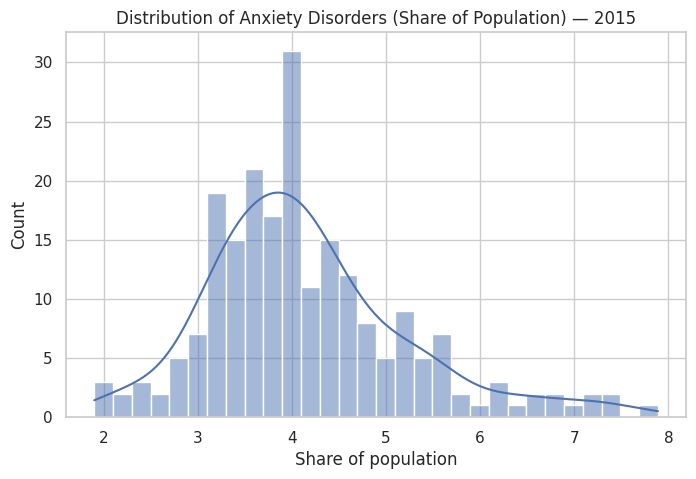

In [ ]:
anxiety_col = "Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized"
sns.set_theme(style="whitegrid")

# Filter to year 2015
mental_health_2015 = mental_health_data[mental_health_data["Year"] == 2015]

plt.figure(figsize=(8, 5))
sns.histplot(
    data=mental_health_2015,
    x=anxiety_col,
    bins=30,
    kde=True
)

plt.title("Distribution of Anxiety Disorders (Share of Population) — 2015")
plt.xlabel("Share of population")
plt.ylabel("Count")
plt.show()


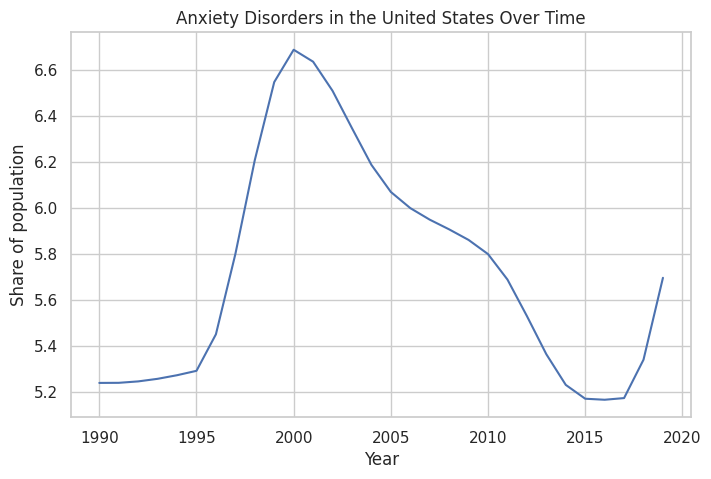

In [ ]:
anxiety_col = "Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized"

# Filter US data
us_anxiety = mental_health_data[
    mental_health_data["Entity"] == "United States"
]

plt.figure(figsize=(8, 5))
plt.plot(
    us_anxiety["Year"],
    us_anxiety[anxiety_col]
)

plt.title("Anxiety Disorders in the United States Over Time")
plt.xlabel("Year")
plt.ylabel("Share of population")
plt.show()


Year-to-year changes are plausible and interpretable, indicating the data is reliable for within-country trend analysis of anxiety disorders.

Looking at the chart, we observe that the share of population affected by a specific disorder in a particular year (anxiety disorder in this case) varies across countries. In addition, the disorder prevalence in a particular country experienced significant fluctuations over time. These variations may provide relevant information for our analysis and comparisons to investigate whether the differences in working hours across those countries are associated with the variations in the prevalence of mental health disorders.

Top 10 countries with the higheset Anxiety Disorder Prevalence

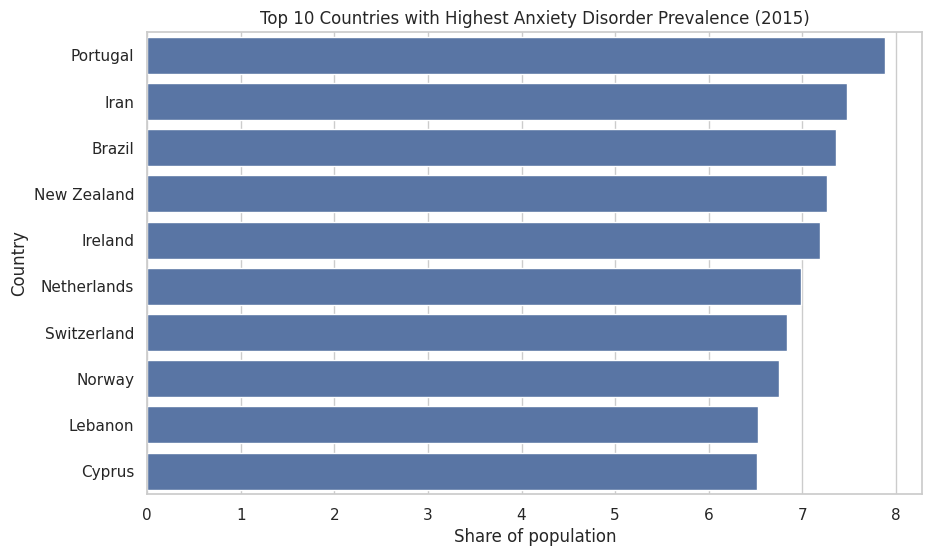

In [ ]:
# Filter to year 2015
mental_health_2015 = mental_health_data[mental_health_data["Year"] == 2015]

top10 = (
    mental_health_2015
      .groupby("Entity")[anxiety_col]
      .max()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x=anxiety_col,
    y="Entity"
)

plt.title("Top 10 Countries with Highest Anxiety Disorder Prevalence (2015)")
plt.xlabel("Share of population")
plt.ylabel("Country")
plt.show()


**Data quality consideration**

We highlight the following quality criteria that we assessed to determine the suitability of the dataset for our problem:

* In terms of completeness, the dataset satisfies our requirement for the task as it spans multiple decades and includes a large number of countries with no misisng values, providing sufficient temporal and geographic coverage for comparative analysis. In addition, based on the data description in Kaggle, the data reflects not only formally diagnosed cases but also prevalence infferred from surveys, capturing individuals who may not have access to healthcare.

* Relevant indicators: it includes a comprehensive set of common mental health disorders, which are highly relevant to our research question.

* The interpretability of the dataset is high, given that it limits to few essential attributes with clear semantics, suggesting misinterpretation and misuse during analysis is unlikely.

**Some limitation for data preparation**

* Aggregated regions: Some entries in the **Entity** column represent regional and income-group aggregates rather than individual countries, which must be handled and filtered carefully in data preparation to avoid double counting.

* Provenance clarity: While the methodology is documented, the Kaggle dataset itself does not list individual contributors or detailed data validation checks, so the quality depends on trust in the original source.

* Survey-based estimates: Some prevalence values are derived from self-reported surveys, which can be influenced by cultural differences in reporting symptoms, social stigma or recall bias.



**Conclusion for Kaggle mental illness prevalence dataset**

Despite those limitations, the dataset ideally fits our data requirements so we eventually opted to use it. We will keep in mind the limitations of the dataset during data preparation and analysis.

### DS4 - World Life Happiness Index Report


**Description:** This Kaggle dataset measures life satisfaction using multiple indicators such as the Life Ladder, GDP per capita, and social support across countries worldwide from 2005 to 2022. By comparing these indicators, we can observe differences in happiness levels between countries and over time. This helps provide a clearer and more comprehensive context for analyzing mental health patterns globally.

Load dataset and display 5 first observations

In [ ]:
file_path = "/content/drive/MyDrive/data/world-happiness-record.csv"
happiness_index_data = pd.read_csv(file_path)
happiness_index_data.head()


,Country Name,Regional Indicator,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption,Positive Affect,Negative Affect,Confidence In National Government
0,Afghanistan,South Asia,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,0.414297,0.258195,0.612072
1,Afghanistan,South Asia,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,0.481421,0.237092,0.611545
2,Afghanistan,South Asia,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,0.516907,0.275324,0.299357
3,Afghanistan,South Asia,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,0.479835,0.267175,0.307386
4,Afghanistan,South Asia,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,0.613513,0.267919,0.435440


**Overall information and description**

In [ ]:
happiness_index_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country Name                       2199 non-null   object 
 1   Regional Indicator                 2087 non-null   object 
 2   Year                               2199 non-null   int64  
 3   Life Ladder                        2199 non-null   float64
 4   Log GDP Per Capita                 2179 non-null   float64
 5   Social Support                     2186 non-null   float64
 6   Healthy Life Expectancy At Birth   2145 non-null   float64
 7   Freedom To Make Life Choices       2166 non-null   float64
 8   Generosity                         2126 non-null   float64
 9   Perceptions Of Corruption          2083 non-null   float64
 10  Positive Affect                    2175 non-null   float64
 11  Negative Affect                    2183 non-null   float

In [ ]:
happiness_index_data.describe()

,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption,Positive Affect,Negative Affect,Confidence In National Government
count,2199.000000,2199.000000,2179.000000,2186.000000,2145.000000,2166.000000,2126.000000,2083.000000,2175.000000,2183.000000,1838.000000
mean,2014.161437,5.479226,9.389766,0.810679,63.294583,0.747858,0.000096,0.745195,0.652143,0.271501,0.483999
std,4.718736,1.125529,1.153387,0.120952,6.901104,0.140150,0.161083,0.185837,0.105922,0.086875,0.193071
min,2005.000000,1.281271,5.526723,0.228217,6.720000,0.257534,-0.337527,0.035198,0.178886,0.082737,0.068769
25%,2010.000000,4.646750,8.499764,0.746609,59.119999,0.656528,-0.112116,0.688139,0.571684,0.207660,0.332549
50%,2014.000000,5.432437,9.498955,0.835535,65.050003,0.769821,-0.022671,0.799654,0.663063,0.260671,0.467140
75%,2018.000000,6.309460,10.373216,0.904792,68.500000,0.859382,0.092070,0.868827,0.737936,0.322894,0.618846
max,2022.000000,8.018934,11.663788,0.987343,74.474998,0.985178,0.702708,0.983276,0.883586,0.704590,0.993604


This dataset is well-structured and contains a rich set of variables that capture multiple dimensions of happiness, including economic, social, health, emotional, and institutional factors. The main variable, Life Ladder, has no missing values, making it reliable for happiness analysis. While some explanatory variables have a small amount of missing data, the overall level of missingness is limited and can be handled with standard data-cleaning methods.

**All countries**

In [ ]:
np.unique(happiness_index_data["Country Name"])

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain',
       'Bangladesh', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo (Brazzaville)', 'Congo (Kinshasa)',
       'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Estonia', 'Eswatini', 'Ethiopia', 'Finland',
       'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guyana', 'Haiti', 'Honduras',
       'Hong Kong S.A.R. of China', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Ivory Coast', 'Jamaica', 'Japan', 

In [ ]:
numbers_of_countries = happiness_index_data.nunique()['Country Name']
print(f"Numbers of country: {numbers_of_countries}")

Numbers of country: 165


The dataset covers a wide range of countries, providing sufficient information for our future analysis and comparisons. All the observations are country-based level, making it convenient to observe trends and insights in a particular country over time. However, as the number of countries is large (165), it may be challenging to make comparisons between individual countries. In data preparation and analysis, it is desireable to group countries based on some criterias and make country-group comparisons.

In addition, some country names do not follow common name convention. For example, the dataset use 'Turkiye' instead of 'Turkey', 'Taiwan Province of China' instead of 'Taiwan' and 'Ivory Coast' instead of 'Cote d'Ivoire'. In data preparation, we need to handle these inconsistencies to ensure accurate analysis and comparisons.


**Distribution of Life Ladder**

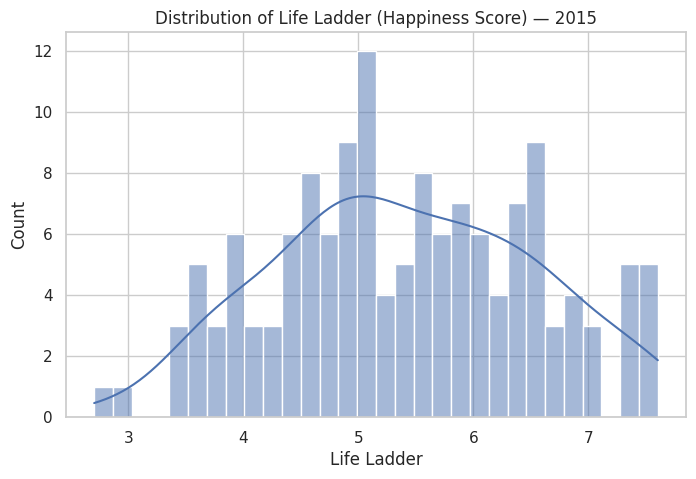

In [ ]:
life_ladder_col = "Life Ladder"
sns.set_theme(style="whitegrid")

# Filter to year 2015
happiness_2015 = happiness_index_data[happiness_index_data["Year"] == 2015]

plt.figure(figsize=(8, 5))
sns.histplot(
    data=happiness_2015,
    x=life_ladder_col,
    bins=30,
    kde=True
)

plt.title("Distribution of Life Ladder (Happiness Score) — 2015")
plt.xlabel("Life Ladder")
plt.ylabel("Count")
plt.show()


This distribution highlights clear differences in happiness levels across countries worldwide, with some countries consistently reporting much higher or lower life satisfaction than others. The wide spread of values indicates substantial global inequality in happiness, making the data useful for comparing regions and identifying underlying factors driving these differences.

Top 10 countries with the higheset Life Ladder

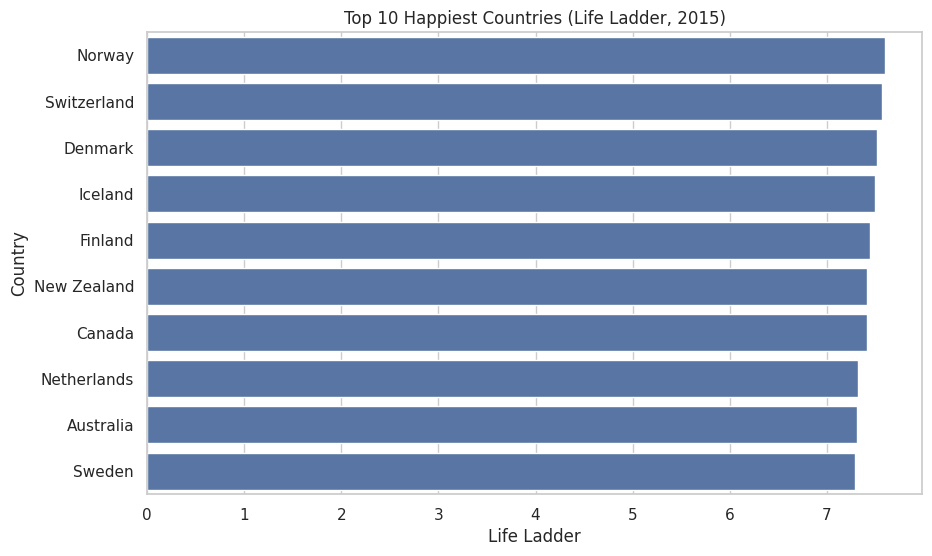

In [ ]:
life_ladder_col = "Life Ladder"

# Filter to year 2015
happiness_2015 = happiness_index_data[happiness_index_data["Year"] == 2015]

top10 = (
    happiness_2015
      .groupby("Country Name")[life_ladder_col]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x=life_ladder_col,
    y="Country Name"
)

plt.title("Top 10 Happiest Countries (Life Ladder, 2015)")
plt.xlabel("Life Ladder")
plt.ylabel("Country")
plt.show()


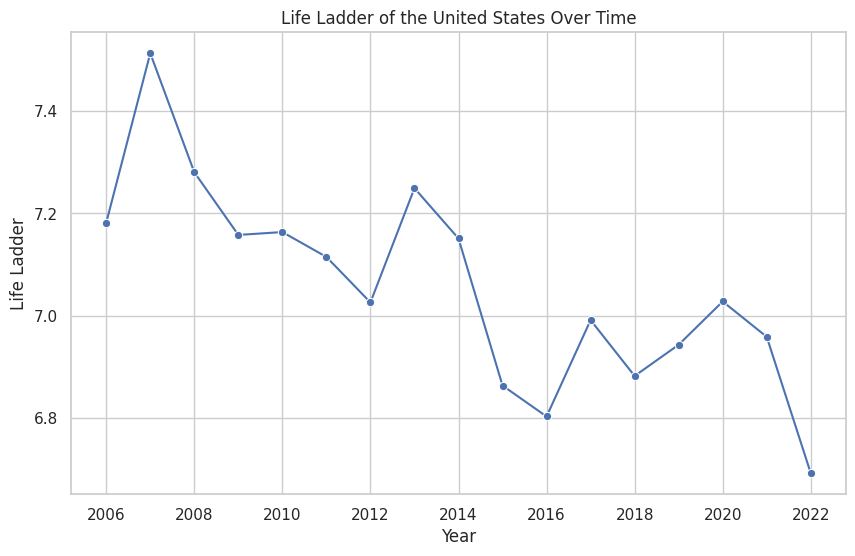

In [ ]:
life_ladder_col = "Life Ladder"

# Filter to United States
us_happiness = happiness_index_data[
    happiness_index_data["Country Name"] == "United States"
].sort_values("Year")

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=us_happiness,
    x="Year",
    y=life_ladder_col,
    marker="o"
)

plt.title("Life Ladder of the United States Over Time")
plt.xlabel("Year")
plt.ylabel("Life Ladder")
plt.grid(True)
plt.show()

**Summary:**
*   Coverage: The dataset includes a large number of countries across multiple regions and years, making it suitable for global mental health analysis.

*   Observations: The number of observations is sufficient to support both cross-country and temporal comparisons.

*   Data quality: There are some missing values, but they are relatively limited and can be handled through standard data cleaning methods.

*   Interpretability: Most variables are intuitive and easy to interpret (e.g., life satisfaction, emotional affect), which helps translate statistical results into clear insights about global mental health differences.

*   Country validity: The country column may contain non-country or duplicated entries, so filtering and validation are necessary before analysis.


*   Provenance clarity: The data source was originally published by the Sustainable Development Solutions Network, with the preparation and research support from highly distinguished centers around the world. The contributors list is comprehensive and measurement definitions are clearly documented, supporting transparency, reproducibility, and appropriate interpretation of results.



**Limitation:**
*   Relevance: Not all indicators are directly related to mental health, so careful variable selection is required to focus on the most meaningful factors.

*   Time span: Although the dataset spans multiple years, it does not extend as far back as expected (e.g., before the 2000), which may limit long-term historical analysis of mental health trends.

* Country name convention: some country names do not follow common name convention. In data preparation, we need to handle these inconsistencies to ensure accurate analysis and comparisons.

# **Assignment 2: Data Preparation (Process)**

**Conclusion of Data Selection**: After carefully evaluating the advanatges and limitations of each dataset, we decided to exclude the second dataset, **Average annual hours actually worked per worker** dataset by OECD Data Explorer. This dataset only covers 46 countries, all of which are already included in the first dataset, **Annual working hours per worker** dataset by Our World in Data. Therefore, using only the first dataset ensures more comprehensive coverage without redundancy.

Other datasets, such as **Mental Illness Prevalence** or **World Life Happiness Index Report** all provide valuable information valuable to find the correlation between Working Hours and Happiness Level. Therefore, we decided to retain these two datasets for data analysis.

### **Data Preparation**



* In this section, describe, justify, and implement transoformation and profiling tasks to prepare the data you have selected for later analysis. Structure the section as follows:
*   Overview: provides a summary of the transformations performed, reffering to the specific types of operations discussed in class. Should include a visualization of the transformation pipeline.
*   For each individual operation (task), briefly describe what it does using terms defined in class, why you perform it, and implement it.





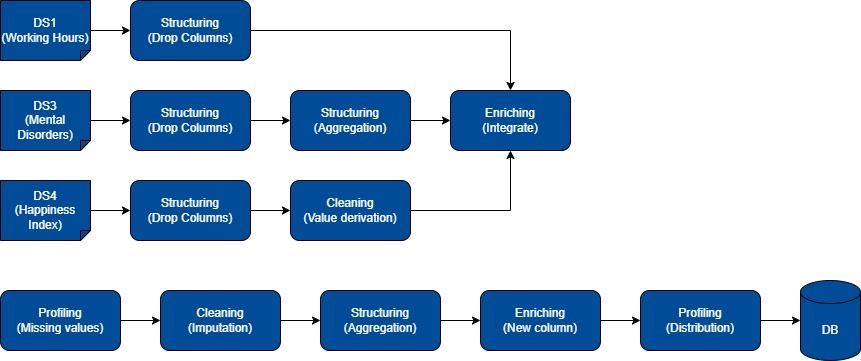

**Intepretation of choosing Year Range**: Our main goal is to analyze the relationship between Working Hours and Level of Happiness across different countries. To achieve this, a longtitudinal analysis spanning a sufficiently long period is required in order to obatin reliable and meaningful results. Several longtitudinal researches has been conducted in finding the impact of long working hours on mental health. For example, one Korean longtitudinal study tracked participants over 7 years to examine gender differences in self-rated health in relation to working hours (Cho et al., 2015). Another Korean panel study also used 7 years of data to investigate the impact of long working hours on depresisve symptoms (Ahn, 2017). In the USA, researchers conducted a study over 10 years examining the onset psychological distress associated with extended working hours (Ezekekwu et al., 2024). These studies indicate that a multi-year period of 7-10 years is appropriate to reliably capture the relationship between working hours and mental health outcomes. Based on our data availability, which spans largely from 1870 to 2023, we decided to focus on a 10-year period to clearly observe and analyze the outcomes.

However, out mental health dataset (dataset 3) only incudes data up to 2019. Therefore, we decided to focus on the 2010-2019 period of our analysis.

###**Data Cleaning: Handle Mismatched Country Names**

We observe that the **Country Name** in three datasets contained some mismatches, likely due to different naming conventions for the same country.

To address this, first, we extracted the country column from each dataset and identified the countries that appeared in all three datasets with the same naming convention. For the remaining countries, which likely had mismatched names across datasets, we used Python librabry `thefuzz` to identify and match nearly identical country names. This approach allowed us to standardize country names and ensure consistecny across all datasets for the analysis. In addition, some mismatched country names could not be identified using the `thefuzz` library alone and required manual verification and domain knowledge to ensure consistency across all tables.

In [ ]:
country_working_hours = df_working_hours.loc[(df_working_hours['Year'] >= 2010) & (df_working_hours['Year'] <= 2019), 'Entity'].drop_duplicates().to_frame()
country_working_hours = country_working_hours.rename(columns={'Entity': 'Country'})
country_working_hours

,Country
5,Albania
24,Algeria
43,Angola
95,Argentina
114,Armenia
...,...
4960,Venezuela
4992,Vietnam
5011,Yemen
5030,Zambia


In [ ]:
country_mental = mental_health_data.loc[(mental_health_data['Year'] >= 2010) & (mental_health_data['Year'] <= 2019), 'Entity'].drop_duplicates().to_frame()
country_mental = country_mental.rename(columns={'Entity': 'Country'})
country_mental

,Country
20,Afghanistan
50,Africa (IHME GBD)
80,Albania
110,Algeria
140,America (IHME GBD)
...,...
6290,Vietnam
6320,World
6350,Yemen
6380,Zambia


In [ ]:
country_happiness = happiness_index_data.loc[(happiness_index_data['Year'] >= 2010) & (happiness_index_data['Year'] <= 2019), 'Country Name'].drop_duplicates().to_frame()
country_happiness = country_happiness.rename(columns={'Country Name': 'Country'})
country_happiness

,Country
2,Afghanistan
16,Albania
29,Algeria
39,Angola
47,Argentina
...,...
2125,Venezuela
2142,Vietnam
2157,Yemen
2171,Zambia


In [ ]:
df = pd.merge(country_working_hours, country_mental, how='inner', on='Country') \
    .merge(country_happiness, how='inner', on='Country')

In [ ]:
countries_only_in_working_hours = country_working_hours[~country_working_hours['Country'].isin(df['Country'])]
print('Countries in country_working_hours but not in df:')
print(countries_only_in_working_hours)


Countries in country_working_hours but not in df:
                           Country
1051                         Congo
1107                 Cote d'Ivoire
1215  Democratic Republic of Congo
1875                     Hong Kong
4398                        Taiwan
4595                        Turkey


In [ ]:
countries_only_in_mental = country_mental[~country_mental['Country'].isin(df['Country'])]
print('Countries in country_mental but not in df:')
for country in countries_only_in_mental['Country']:
  print(country)

Countries in country_mental but not in df:
Afghanistan
Africa (IHME GBD)
America (IHME GBD)
American Samoa
Andorra
Antigua and Barbuda
Asia (IHME GBD)
Bahamas
Barbados
Belize
Benin
Bermuda
Bhutan
Brunei
Burundi
Cape Verde
Central African Republic
Comoros
Congo
Cook Islands
Cote d'Ivoire
Cuba
Democratic Republic of Congo
Djibouti
Dominica
East Timor
El Salvador
Equatorial Guinea
Eritrea
Eswatini
Europe (IHME GBD)
European Union (27)
Fiji
Gambia
Greenland
Grenada
Guam
Guinea
Guinea-Bissau
Guyana
Haiti
High-income countries
Honduras
Kiribati
Laos
Lesotho
Liberia
Libya
Low-income countries
Lower-middle-income countries
Maldives
Marshall Islands
Mauritania
Micronesia (country)
Monaco
Mongolia
Montenegro
Nauru
Nepal
Nicaragua
Niue
North Korea
Northern Mariana Islands
Palau
Palestine
Panama
Papua New Guinea
Puerto Rico
Saint Kitts and Nevis
Saint Lucia
Saint Vincent and the Grenadines
Samoa
San Marino
Sao Tome and Principe
Seychelles
Sierra Leone
Solomon Islands
Somalia
South Sudan
Suriname
T

In [ ]:
countries_only_in_happiness = country_happiness[~country_happiness['Country'].isin(df['Country'])]
print('Countries in country_happiness but not in df:')
print(countries_only_in_happiness)

Countries in country_happiness but not in df:
                        Country
2                   Afghanistan
180                      Belize
183                       Benin
195                      Bhutan
290                     Burundi
345    Central African Republic
415                     Comoros
422         Congo (Brazzaville)
435            Congo (Kinshasa)
524                    Djibouti
581                 El Salvador
610                    Eswatini
667                      Gambia
753                      Guinea
768                       Haiti
781                    Honduras
796   Hong Kong S.A.R. of China
944                 Ivory Coast
1034                     Kosovo
1078                       Laos
1118                    Lesotho
1124                    Liberia
1132                      Libya
1207                   Maldives
1241                 Mauritania
1297                   Mongolia
1312                 Montenegro
1367                      Nepal
1416                  Nica

In [ ]:
pip install thefuzz

In [ ]:
from thefuzz import process

for country in countries_only_in_happiness['Country']:
  match, score, _ = process.extractOne(country, countries_only_in_working_hours['Country'])
  if score >= 90:
    print(f"Matched: {country} -> {match}")

Matched: Congo (Brazzaville) -> Congo
Matched: Congo (Kinshasa) -> Congo
Matched: Hong Kong S.A.R. of China -> Hong Kong
Matched: Taiwan Province of China -> Taiwan


In [ ]:
from thefuzz import process

for country in countries_only_in_mental['Country']:
  match, score, _ = process.extractOne(country, countries_only_in_working_hours['Country'])
  if score >= 90:
    print(f"Matched: {country} -> {match}")

Matched: Congo -> Congo
Matched: Cote d'Ivoire -> Cote d'Ivoire
Matched: Democratic Republic of Congo -> Democratic Republic of Congo
Matched: Taiwan -> Taiwan
Matched: Turkey -> Turkey


In [ ]:
from thefuzz import process

for country in countries_only_in_happiness['Country']:
  match, score, _ = process.extractOne(country, countries_only_in_mental['Country'])
  if score >= 90:
    print(f"Matched: {country} -> {match}")

Matched: Afghanistan -> Afghanistan
Matched: Belize -> Belize
Matched: Benin -> Benin
Matched: Bhutan -> Bhutan
Matched: Burundi -> Burundi
Matched: Central African Republic -> Central African Republic
Matched: Comoros -> Comoros
Matched: Congo (Brazzaville) -> Congo
Matched: Congo (Kinshasa) -> Congo
Matched: Djibouti -> Djibouti
Matched: El Salvador -> El Salvador
Matched: Eswatini -> Eswatini
Matched: Gambia -> Gambia
Matched: Guinea -> Guinea
Matched: Haiti -> Haiti
Matched: Honduras -> Honduras
Matched: Laos -> Laos
Matched: Lesotho -> Lesotho
Matched: Liberia -> Liberia
Matched: Libya -> Libya
Matched: Maldives -> Maldives
Matched: Mauritania -> Mauritania
Matched: Mongolia -> Mongolia
Matched: Montenegro -> Montenegro
Matched: Nepal -> Nepal
Matched: Nicaragua -> Nicaragua
Matched: Panama -> Panama
Matched: Sierra Leone -> Sierra Leone
Matched: Somalia -> Somalia
Matched: South Sudan -> South Sudan
Matched: State of Palestine -> Palestine
Matched: Suriname -> Suriname
Matched: T

We observe that most of the mismatched country names happens in the Happiness dataset (dataset 4):

Turkiye --> Turkey, Taiwan Province of China --> Taiwan,  Hong Kong S.A.R of China --> Hongkong, State of Palestine --> Palestine, Ivory Coast --> Cote d'Ivoire, Congo (Brazzaville) --> Congo, Congo (Kinshasa) --> Democratic Republic of Congo

In [ ]:
happiness_index_data['Country Name'] = happiness_index_data['Country Name'].replace('Turkiye', 'Turkey')
happiness_index_data['Country Name'] = happiness_index_data['Country Name'].replace('Taiwan Province of China', 'Taiwan')
happiness_index_data['Country Name'] = happiness_index_data['Country Name'].replace('Hong Kong S.A.R of China', 'Hong Kong')
happiness_index_data['Country Name'] = happiness_index_data['Country Name'].replace('State of Palestine', 'Palestine')
happiness_index_data['Country Name'] = happiness_index_data['Country Name'].replace('Ivory Coast', 'Cote d\'Ivoire')
happiness_index_data['Country Name'] = happiness_index_data['Country Name'].replace('Congo (Brazzaville)', 'Congo')
happiness_index_data['Country Name'] = happiness_index_data['Country Name'].replace('Congo (Kinshasa)', 'Democratic Republic of Congo')


### **Select important columns, Rename and Merge**

**Dataset 1: delete country code**

In [ ]:
# 1. Define the columns to keep
selected_cols1 = ['Entity', 'Year', 'Working hours per worker']

# 2. Filter the working hours dataframe
selected_working_hours = df_working_hours[selected_cols1]

# 3. Rename 'Entity' to 'Country' to facilitate merging
selected_working_hours = selected_working_hours.rename(columns={'Entity': 'Country'})

# Display the first few rows to verify
print(selected_working_hours.head())

   Country  Year  Working hours per worker
0  Albania  2005                   2343.90
1  Albania  2006                   2333.12
2  Albania  2007                   2334.51
3  Albania  2008                   2195.57
4  Albania  2009                   2191.19


**Dataset 4: Keep the 2 most important columns about happiness index, and Log GDP Per Capia to classify countries by economy status.**



In [ ]:
selected_cols = ['Country Name', 'Year', 'Life Ladder', 'Freedom To Make Life Choices', 'Log GDP Per Capita']
selected_happiness = happiness_index_data[selected_cols].copy()

# 2. Rename 'Country Name' to 'Country' to match your other dataframe
selected_happiness = selected_happiness.rename(columns={'Country Name': 'Country'})
selected_happiness.head()

,Country,Year,Life Ladder,Freedom To Make Life Choices,Log GDP Per Capita
0,Afghanistan,2008,3.723590,0.718114,7.350416
1,Afghanistan,2009,4.401778,0.678896,7.508646
2,Afghanistan,2010,4.758381,0.600127,7.613900
3,Afghanistan,2011,3.831719,0.495901,7.581259
4,Afghanistan,2012,3.782938,0.530935,7.660506


**Dataset 3: Keep Depressive and Anxiety Disorders. For the others, we calculate their sum.**

In [ ]:
selected_columns = [
    'Entity',
    'Year',
    'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized',
    'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized',
    'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized',
    'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized',
    'Eating disorders (share of population) - Sex: Both - Age: Age-standardized'
]
mental_health_cleaned = mental_health_data[selected_columns].copy()

# Identify columns to be grouped under 'Others'
other_disorder_cols = [
    'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized',
    'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized',
    'Eating disorders (share of population) - Sex: Both - Age: Age-standardized'
]

# Sum these columns into a new 'Others' column
mental_health_cleaned['Others'] = mental_health_cleaned[other_disorder_cols].sum(axis=1)

# Drop the original 'other disorder' columns
mental_health_cleaned = mental_health_cleaned.drop(columns=other_disorder_cols)

# Rename the remaining disorder columns for clarity
mental_health_cleaned = mental_health_cleaned.rename(columns={
    'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized': 'Depressive disorders',
    'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized': 'Anxiety disorders'
})
mental_health_cleaned = mental_health_cleaned.rename(columns={'Entity': 'Country'})

# Display the first few rows of the cleaned DataFrame
display(mental_health_cleaned.head())

,Country,Year,Depressive disorders,Anxiety disorders,Others
0,Afghanistan,1990,4.996118,4.713314,1.053929
1,Afghanistan,1991,4.989290,4.702100,1.047779
2,Afghanistan,1992,4.981346,4.683743,1.041387
3,Afghanistan,1993,4.976958,4.673549,1.036163
4,Afghanistan,1994,4.977782,4.670810,1.031896


### **Merging datasets**

In this merging, we use inner join to join datasets by country and year. At the same time we filter the dataset to cover time range from 2010 to 2019.

In [ ]:
pip install pandasql

In [ ]:
from pandasql import sqldf

# Rename 'Country Name' to 'Country' in selected_happiness for consistent merging
selected_happiness_renamed = selected_happiness.rename(columns={'Country Name': 'Country'})

# Rename 'Entity' to 'Country' in mental_health_cleaned for consistent merging
mental_health_cleaned_renamed = mental_health_cleaned.rename(columns={'Entity': 'Country'})

# Rename 'Entity' to 'Country' in df_working_hours for consistent merging
df_working_hours_renamed = df_working_hours.rename(columns={'Entity': 'Country'})

# Define the SQL query to join the three dataframes
query = """
SELECT
    wh.Country,
    wh.Year,
    wh."Working hours per worker" as Working_hours_per_worker,
    sh."Life Ladder" as Life_Ladder,
    sh."Freedom To Make Life Choices" as Freedom_To_Make_Life_Choices,
    sh."Log GDP Per Capita" as Log_GDP_Per_Capita,
    mh."Depressive disorders" as Depressive_disorders,
    mh."Anxiety disorders" as Anxiety_disorders,
    mh."Others" as Other_mental_disorders
FROM
    df_working_hours_renamed wh
INNER JOIN
    selected_happiness_renamed sh ON wh.Country = sh.Country AND wh.Year = sh.Year
INNER JOIN
    mental_health_cleaned_renamed mh ON wh.Country = mh.Country AND wh.Year = mh.Year
WHERE wh.Year >= 2010 AND wh.Year <= 2019
"""

# Execute the SQL query
merged_df = sqldf(query, globals())

# Display the first few rows of the merged DataFrame
display(merged_df.head())

,Country,Year,Working_hours_per_worker,Life_Ladder,Freedom_To_Make_Life_Choices,Log_GDP_Per_Capita,Depressive_disorders,Anxiety_disorders,Other_mental_disorders
0,Albania,2010,2119.70,5.268937,0.568958,9.282793,2.442718,3.757140,0.950564
1,Albania,2011,1852.72,5.867422,0.487496,9.310619,2.441195,3.767038,0.952637
2,Albania,2012,2054.16,5.510124,0.601512,9.326344,2.440708,3.781654,0.954557
3,Albania,2013,2128.41,4.550648,0.631830,9.338146,2.441420,3.797746,0.956769
4,Albania,2014,1946.22,4.813763,0.734648,9.357805,2.442242,3.811362,0.958686


In [ ]:
display(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178 entries, 0 to 1177
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       1178 non-null   object 
 1   Year                          1178 non-null   int64  
 2   Working_hours_per_worker      1178 non-null   float64
 3   Life_Ladder                   1178 non-null   float64
 4   Freedom_To_Make_Life_Choices  1160 non-null   float64
 5   Log_GDP_Per_Capita            1178 non-null   float64
 6   Depressive_disorders          1178 non-null   float64
 7   Anxiety_disorders             1178 non-null   float64
 8   Other_mental_disorders        1178 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 83.0+ KB


None

In [ ]:
unique_countries_in_merged_df = merged_df['Country'].unique()
print("Unique countries in merged_df:")
for country in unique_countries_in_merged_df:
    print(country)
print(f"\nTotal unique countries: {len(unique_countries_in_merged_df)}")

Unique countries in merged_df:
Albania
Algeria
Angola
Argentina
Armenia
Australia
Austria
Azerbaijan
Bahrain
Bangladesh
Belarus
Belgium
Bolivia
Bosnia and Herzegovina
Botswana
Brazil
Bulgaria
Burkina Faso
Cambodia
Cameroon
Canada
Chad
Chile
China
Colombia
Congo
Costa Rica
Cote d'Ivoire
Croatia
Cyprus
Czechia
Democratic Republic of Congo
Denmark
Dominican Republic
Ecuador
Egypt
Estonia
Ethiopia
Finland
France
Gabon
Georgia
Germany
Ghana
Greece
Guatemala
Hungary
Iceland
India
Indonesia
Iran
Iraq
Ireland
Israel
Italy
Jamaica
Japan
Jordan
Kazakhstan
Kenya
Kuwait
Kyrgyzstan
Latvia
Lebanon
Lithuania
Luxembourg
Madagascar
Malawi
Malaysia
Mali
Malta
Mauritius
Mexico
Moldova
Morocco
Mozambique
Myanmar
Namibia
Netherlands
New Zealand
Niger
Nigeria
North Macedonia
Norway
Oman
Pakistan
Paraguay
Peru
Philippines
Poland
Portugal
Qatar
Romania
Russia
Rwanda
Saudi Arabia
Senegal
Serbia
Singapore
Slovakia
Slovenia
South Africa
South Korea
Spain
Sri Lanka
Sudan
Sweden
Switzerland
Syria
Taiwan
Tajikistan

In [ ]:
unique_years_in_merged_df = merged_df['Year'].unique()
print("Unique years in merged_df:")
for year in unique_years_in_merged_df:
    print(year)
print(f"\nTotal unique years: {len(unique_years_in_merged_df)}")

Unique years in merged_df:
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019

Total unique years: 10


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178 entries, 0 to 1177
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       1178 non-null   object 
 1   Year                          1178 non-null   int64  
 2   Working_hours_per_worker      1178 non-null   float64
 3   Life_Ladder                   1178 non-null   float64
 4   Freedom_To_Make_Life_Choices  1160 non-null   float64
 5   Log_GDP_Per_Capita            1178 non-null   float64
 6   Depressive_disorders          1178 non-null   float64
 7   Anxiety_disorders             1178 non-null   float64
 8   Other_mental_disorders        1178 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 83.0+ KB


Evaluate: after merging, over 30 countries do not have enough data for the whole 10 years, so we need to do cleaning and filling missing values

### **Cleaning and Filling Missing Values**

From the previous part, after merging, there are 129 countries but only 1178 entries for the 10-year period. Hence, this section focuses on the following key steps:
* **Filter by Data Completeness**: Identify and retain only those countries that have a substantial number of years of data (e.g., 8 out of 10 years) within the 2010-2019 period. This ensures sufficiently continuous data, and minimizes potential biases.
* **Imputation of Missing Values**: For the countries that meet the data completeness criteria, we will use linear interpolation to fill in any gaps in the numerical columns for the years 2010-2019. After linear interpolation, forward-fill and backward-fill methods will be applied to handle any remaining `NaN` values at the beginning or end of a country's time series. If a numerical column remains entirely `NaN` for a country these will be imputed with the global mean of that column across the entire dataset to ensure no data is lost.


In [ ]:
# Filter merged_df for years 2010-2019
merged_df_filtered_years = merged_df[(merged_df['Year'] >= 2010) & (merged_df['Year'] <= 2019)].copy()

# Calculate the number of unique years for each country
year_counts_per_country_merged = merged_df_filtered_years.groupby('Country')['Year'].nunique()

# Identify countries that have data for 8 to 10 years (inclusive) within the 2010-2019 range
countries_to_keep_merged = year_counts_per_country_merged[(year_counts_per_country_merged >= 8) & (year_counts_per_country_merged <= 10)].index

# Filter the DataFrame to include only these countries
merged_df_processed = merged_df_filtered_years[merged_df_filtered_years['Country'].isin(countries_to_keep_merged)].copy()

# Ensure all years from 2010 to 2019 are present for each country and interpolate
all_years_range = pd.RangeIndex(start=2010, stop=2020, name='Year')

# Define numerical columns for imputation
numerical_cols = [
    'Working_hours_per_worker', 'Life_Ladder', 'Freedom_To_Make_Life_Choices',
    'Log_GDP_Per_Capita', 'Depressive_disorders', 'Anxiety_disorders',
    'Other_mental_disorders'
]

def interpolate_merged_data(df_country):
    # Set 'Year' as index for reindexing and interpolation
    df_country_indexed = df_country.set_index('Year')
    # Reindex to have all years from 2010 to 2019
    df_country_reindexed = df_country_indexed.reindex(all_years_range)

    for col in numerical_cols:
        # First, apply linear interpolation for values between known points
        df_country_reindexed[col] = df_country_reindexed[col].interpolate(method='linear')
        # Then, forward fill and backward fill to handle NaNs at the beginning/end of the series
        # If a column was entirely NaN for a country, ffill().bfill() will not fill it, it remains NaN
        df_country_reindexed[col] = df_country_reindexed[col].ffill().bfill()

    # Fill 'Country' for newly added rows
    df_country_reindexed['Country'] = df_country_indexed['Country'].iloc[0]
    return df_country_reindexed.reset_index()

# Apply the interpolation function to each country group
merged_df_processed_interpolated = merged_df_processed.groupby('Country', group_keys=False).apply(interpolate_merged_data)

# Final step: Fill any remaining NaNs that could not be interpolated country-wise
# This happens if a country had all NaNs for a specific numerical column throughout the 2010-2019 period.
# Fill these remaining NaNs with the mean of the respective column from the *entire* interpolated DataFrame.
for col in numerical_cols:
    if merged_df_processed_interpolated[col].isnull().any():
        global_mean = merged_df_processed_interpolated[col].mean()
        merged_df_processed_interpolated[col].fillna(global_mean, inplace=True)

display(merged_df_processed_interpolated.head())


/tmp/ipykernel_18086/2342071153.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_df_processed_interpolated = merged_df_processed.groupby('Country', group_keys=False).apply(interpolate_merged_data)


,Year,Country,Working_hours_per_worker,Life_Ladder,Freedom_To_Make_Life_Choices,Log_GDP_Per_Capita,Depressive_disorders,Anxiety_disorders,Other_mental_disorders
0,2010,Albania,2119.70,5.268937,0.568958,9.282793,2.442718,3.757140,0.950564
1,2011,Albania,1852.72,5.867422,0.487496,9.310619,2.441195,3.767038,0.952637
2,2012,Albania,2054.16,5.510124,0.601512,9.326344,2.440708,3.781654,0.954557
3,2013,Albania,2128.41,4.550648,0.631830,9.338146,2.441420,3.797746,0.956769
4,2014,Albania,1946.22,4.813763,0.734648,9.357805,2.442242,3.811362,0.958686


In [ ]:
# Check info for the processed DataFrame to see non-null counts after interpolation
display(merged_df_processed_interpolated.info())


<class 'pandas.core.frame.DataFrame'>
Index: 1130 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          1130 non-null   int64  
 1   Country                       1130 non-null   object 
 2   Working_hours_per_worker      1130 non-null   float64
 3   Life_Ladder                   1130 non-null   float64
 4   Freedom_To_Make_Life_Choices  1130 non-null   float64
 5   Log_GDP_Per_Capita            1130 non-null   float64
 6   Depressive_disorders          1130 non-null   float64
 7   Anxiety_disorders             1130 non-null   float64
 8   Other_mental_disorders        1130 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 88.3+ KB


None

In [ ]:
# Verify the number of years per country after interpolation
year_counts_after_interpolation_merged = merged_df_processed_interpolated.groupby('Country')['Year'].nunique()
print("Number of years per country in merged_df after processing and interpolation:")
display(year_counts_after_interpolation_merged)

print(f"Total unique countries in merged_df after processing: {merged_df_processed_interpolated['Country'].nunique()}")


Number of years per country in merged_df after processing and interpolation:


,Year
Country,
Albania,10
Algeria,10
Argentina,10
Armenia,10
Australia,10
...,...
Uzbekistan,10
Vietnam,10
Yemen,10


Total unique countries in merged_df after processing: 113


In [ ]:
merged_df_processed_interpolated.describe()

,Year,Working_hours_per_worker,Life_Ladder,Freedom_To_Make_Life_Choices,Log_GDP_Per_Capita,Depressive_disorders,Anxiety_disorders,Other_mental_disorders
count,1130.000000,1130.000000,1130.000000,1130.000000,1130.000000,1130.000000,1130.000000,1130.000000
mean,2014.500000,1959.933230,5.546390,0.760352,9.548518,3.648534,4.203035,1.168753
std,2.873553,302.402668,1.083577,0.131975,1.084559,0.883165,1.286476,0.370587
min,2010.000000,1331.550000,2.693523,0.314565,6.918029,1.943582,2.005040,0.575981
25%,2012.000000,1707.742500,4.724587,0.667316,8.848164,2.964889,3.339840,0.891578
50%,2014.500000,1971.740000,5.534061,0.779276,9.604992,3.646081,3.925303,1.010250
75%,2017.000000,2172.097500,6.358593,0.868410,10.469400,4.192006,4.914944,1.456005
max,2019.000000,2706.890000,7.858107,0.985178,11.663788,7.033014,8.496533,2.545395


### **Group countries by economic status**

This enriching step calculate GDP per capita in every country for each year, and classify them into UnderDeveloped, Developing, Developed. If one's status changes, we notes status1_to_status2

In [ ]:
import numpy as np

# 1. Standardizing the Real GDP Calculation
merged_df_processed_interpolated['Real_GDP_USD'] = np.exp(merged_df_processed_interpolated['Log_GDP_Per_Capita'])

# 2. Define the classification function (keeping your specific thresholds)
def get_single_status(gdp):
    if gdp >= 30000:
        return 'Developed'
    elif 5000 <= gdp < 30000:
        return 'Developing'
    else:
        return 'Underdeveloped'

# 3. Calculate 10-year Average and Apply Thresholds
# Group by country to find the mean GDP across the decade
country_avg_stats = (
    merged_df_processed_interpolated
    .groupby('Country')['Real_GDP_USD']
    .mean()
    .reset_index()
)

# Apply your threshold function to the average
country_avg_stats['Economic_Group'] = country_avg_stats['Real_GDP_USD'].apply(get_single_status)

# 4. Map the group back to the original dataframe
# This assigns the same status to every year for a country
status_map = dict(zip(country_avg_stats['Country'], country_avg_stats['Economic_Group']))
merged_df_processed_interpolated['Economic_Group'] = merged_df_processed_interpolated['Country'].map(status_map)

# 5. Verification: Check the distribution of your 3 groups
print("Country counts per group:")
print(country_avg_stats['Economic_Group'].value_counts())

Country counts per group:
Economic_Group
Developing        56
Developed         33
Underdeveloped    24
Name: count, dtype: int64


In [ ]:
merged_df_processed_interpolated.head(100)

,Year,Country,Working_hours_per_worker,Life_Ladder,Freedom_To_Make_Life_Choices,Log_GDP_Per_Capita,Depressive_disorders,Anxiety_disorders,Other_mental_disorders,Real_GDP_USD,Economic_Group
0,2010,Albania,2119.70,5.268937,0.568958,9.282793,2.442718,3.757140,0.950564,10751.419217,Developing
1,2011,Albania,1852.72,5.867422,0.487496,9.310619,2.441195,3.767038,0.952637,11054.792839,Developing
2,2012,Albania,2054.16,5.510124,0.601512,9.326344,2.440708,3.781654,0.954557,11229.994253,Developing
3,2013,Albania,2128.41,4.550648,0.631830,9.338146,2.441420,3.797746,0.956769,11363.323487,Developing
4,2014,Albania,1946.22,4.813763,0.734648,9.357805,2.442242,3.811362,0.958686,11588.925838,Developing
...,...,...,...,...,...,...,...,...,...,...,...
5,2015,Belarus,1814.65,5.718908,0.622753,9.818079,3.892835,3.490736,0.929456,18362.741919,Developing
6,2016,Belarus,1806.66,5.177899,0.658229,9.791613,3.895392,3.486121,0.930619,17883.121696,Developing
7,2017,Belarus,1825.62,5.552915,0.620979,9.817718,3.894381,3.481371,0.931775,18356.106033,Developing
8,2018,Belarus,1843.25,5.233770,0.643602,9.850862,3.870581,3.480940,0.932104,18974.695392,Developing


/tmp/ipykernel_18086/4165882026.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


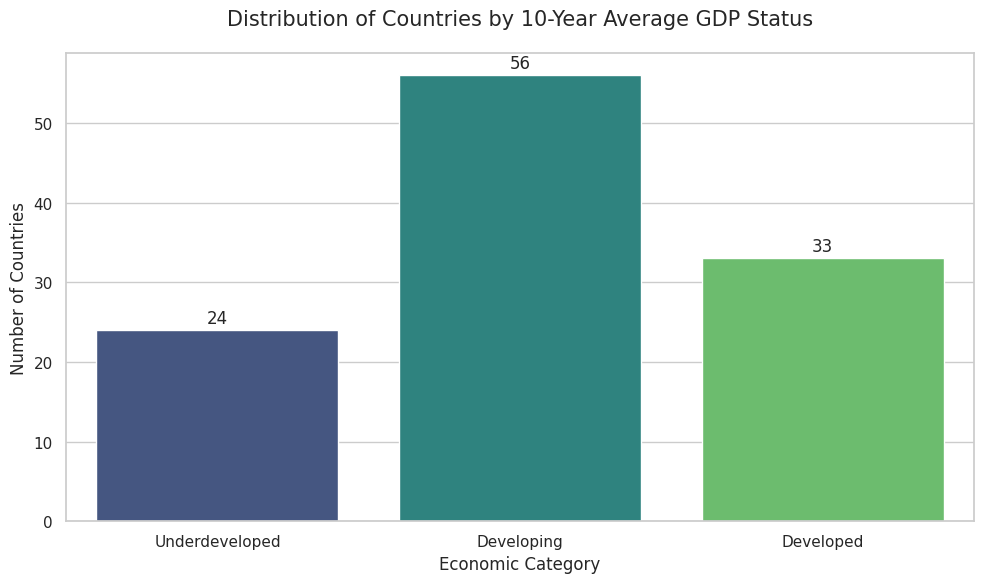

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data for plotting
# We want to count unique countries per group, not just the number of rows
plot_data = (
    merged_df_processed_interpolated
    .groupby('Economic_Group')['Country']
    .nunique()
    .reset_index()
    .rename(columns={'Country': 'Country_Count'})
)

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the Bar Chart
# Note: We specify the order to ensure 'Developed' is on the right
category_order = ['Underdeveloped', 'Developing', 'Developed']

ax = sns.barplot(
    data=plot_data,
    x='Economic_Group',
    y='Country_Count',
    order=category_order,
    palette='viridis'
)

# 4. Add labels and title
plt.title('Distribution of Countries by 10-Year Average GDP Status', fontsize=15, pad=20)
plt.xlabel('Economic Category', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)

# Optional: Add the count numbers on top of each bar for clarity
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

### **Grouping countries by Working Hours**

We categorize country by the levels of working hours(high, medium, low). We calculate the average weekly working hours for the countries, then categorize the countries by quantile thresholds to ensure data balance:
- < 33rd percentile: low
- 33rd-66th percentile: medium
- \> 66th percentile: high


In [ ]:
import numpy as np

# Calculate the average annual working hours for each country over the 2010-2019 period
country_aggregated_hours = merged_df_processed_interpolated.groupby('Country')['Working_hours_per_worker'].mean().reset_index()
country_aggregated_hours = country_aggregated_hours.rename(columns={'Working_hours_per_worker': 'Average_Annual_Working_hours_2010_2019'})

# Convert average annual working hours to average weekly working hours (assuming 52 weeks/year)
country_aggregated_hours['Average_Weekly_Working_hours_2010_2019'] = country_aggregated_hours['Average_Annual_Working_hours_2010_2019'] / 52

# Define the quantile thresholds for 'low', 'medium', and 'high' categories
# For example, 33rd and 66th percentiles for three categories
low_threshold_quantile = country_aggregated_hours['Average_Weekly_Working_hours_2010_2019'].quantile(0.33)
high_threshold_quantile = country_aggregated_hours['Average_Weekly_Working_hours_2010_2019'].quantile(0.66)

# Define a function to assign categories based on the average weekly hours using quantiles
def assign_country_category_by_quantile(weekly_hours):
    if weekly_hours < low_threshold_quantile:
        return 'low'
    elif weekly_hours <= high_threshold_quantile:
        return 'medium'
    else:
        return 'high'

# Apply the categorization to the aggregated country data
country_aggregated_hours['Working_hours_Category_2010_2019'] = country_aggregated_hours['Average_Weekly_Working_hours_2010_2019'].apply(assign_country_category_by_quantile)

# Display the aggregated and categorized data for each country
display(country_aggregated_hours.head())

,Country,Average_Annual_Working_hours_2010_2019,Average_Weekly_Working_hours_2010_2019,Working_hours_Category_2010_2019
0,Albania,2046.8070,39.361673,medium
1,Algeria,2231.3585,42.910740,high
2,Argentina,1693.7200,32.571538,low
3,Armenia,1934.4040,37.200077,medium
4,Australia,1648.7730,31.707173,low


In [ ]:
# Display the distribution of countries across the new working hours categories
print("Distribution of countries by Working Hours Category (2010-2019 Average) based on quantiles:")
display(country_aggregated_hours['Working_hours_Category_2010_2019'].value_counts())

Distribution of countries by Working Hours Category (2010-2019 Average) based on quantiles:


,count
Working_hours_Category_2010_2019,
high,39
medium,37
low,37


/tmp/ipykernel_18086/2408347188.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Working_hours_Category_2010_2019', data=country_aggregated_hours, palette='viridis', order=['low', 'medium', 'high'])


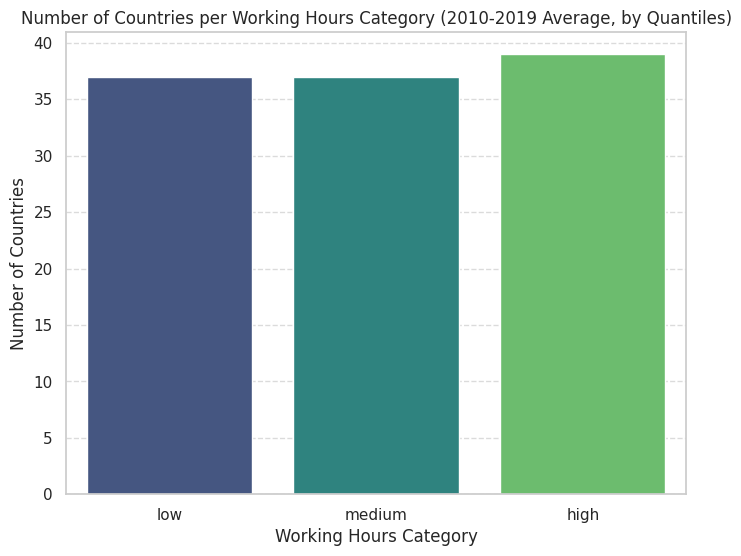

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a countplot for the 'Working_hours_Category_2010_2019'
plt.figure(figsize=(8, 6))
sns.countplot(x='Working_hours_Category_2010_2019', data=country_aggregated_hours, palette='viridis', order=['low', 'medium', 'high'])

plt.title('Number of Countries per Working Hours Category (2010-2019 Average, by Quantiles)')
plt.xlabel('Working Hours Category')
plt.ylabel('Number of Countries')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Merge the working hours category into the main interpolated DataFrame
merged_df_processed_interpolated = pd.merge(
    merged_df_processed_interpolated,
    country_aggregated_hours[['Country', 'Working_hours_Category_2010_2019']],
    on='Country',
    how='left'
)

display(merged_df_processed_interpolated.head())

,Year,Country,Working_hours_per_worker,Life_Ladder,Freedom_To_Make_Life_Choices,Log_GDP_Per_Capita,Depressive_disorders,Anxiety_disorders,Other_mental_disorders,Real_GDP_USD,Economic_Group,Working_hours_Category_2010_2019
0,2010,Albania,2119.70,5.268937,0.568958,9.282793,2.442718,3.757140,0.950564,10751.419217,Developing,medium
1,2011,Albania,1852.72,5.867422,0.487496,9.310619,2.441195,3.767038,0.952637,11054.792839,Developing,medium
2,2012,Albania,2054.16,5.510124,0.601512,9.326344,2.440708,3.781654,0.954557,11229.994253,Developing,medium
3,2013,Albania,2128.41,4.550648,0.631830,9.338146,2.441420,3.797746,0.956769,11363.323487,Developing,medium
4,2014,Albania,1946.22,4.813763,0.734648,9.357805,2.442242,3.811362,0.958686,11588.925838,Developing,medium


# **Assignment 3: Data Analysis (Analyze)**

In [ ]:
final_df = merged_df_processed_interpolated.copy()

Given that our ovarching goal is to determine if there is a relationship between working hours and well-being conditions, we apply the following methods from descritpive and diagnostic analysis:

* **Visualization (Descriptive analysis)**
* **Relationship and dependency analysis (Diagnostic analysis)**
* **Hypothesis Testing and Validation (Diagnostic analysis)**


### **Well-being indicators among different working hour groups during the 10-year period**

Firstly, we plot graphs to see the difference in happiness and mental issues between groups of working hour over years.

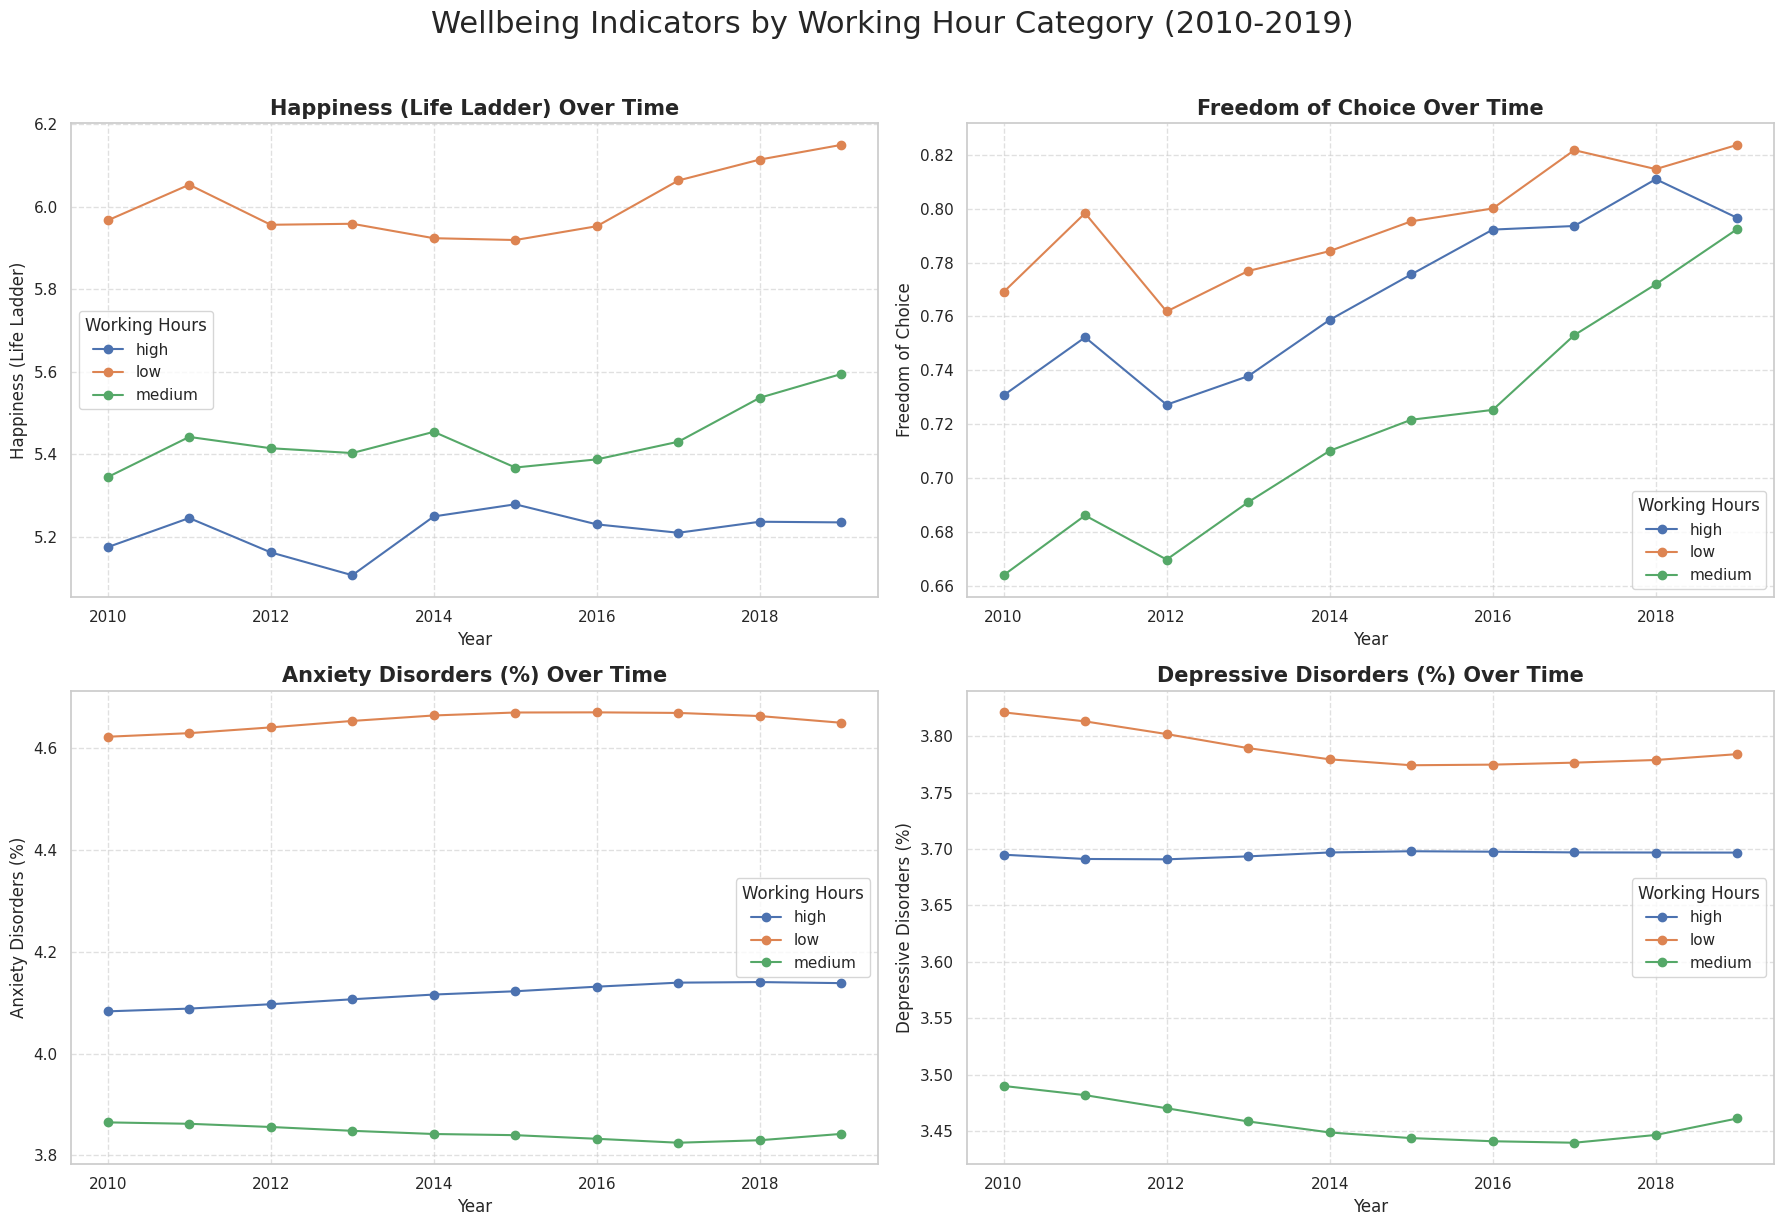

In [ ]:
import matplotlib.pyplot as plt

# 1. Setup the figure and a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Define the features we want to plot
features = [
    ('Life_Ladder', 'Happiness (Life Ladder)'),
    ('Freedom_To_Make_Life_Choices', 'Freedom of Choice'),
    ('Anxiety_disorders', 'Anxiety Disorders (%)'),
    ('Depressive_disorders', 'Depressive Disorders (%)')
]

# 2. Loop through the features and the axes to generate the 4 graphs
for i, (col_name, display_name) in enumerate(features):
    # Calculate the mean for the specific feature
    grouped = final_df.groupby(['Year', 'Working_hours_Category_2010_2019'])[col_name].mean().reset_index()

    # Plot each working hour category
    for group in grouped['Working_hours_Category_2010_2019'].unique():
        subset = grouped[grouped['Working_hours_Category_2010_2019'] == group]
        axes[i].plot(subset['Year'], subset[col_name], marker='o', label=group)

    # Formatting each subplot
    axes[i].set_title(f'{display_name} Over Time', fontsize=15, fontweight='bold')
    axes[i].set_ylabel(display_name)
    axes[i].set_xlabel('Year')
    axes[i].legend(title="Working Hours")
    axes[i].grid(True, linestyle='--', alpha=0.6)

# 3. Global formatting
plt.suptitle('Wellbeing Indicators by Working Hour Category (2010-2019)', fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

In the first graph illustrating the relationship between Happiness Level (Life Ladder) among different working-hour groups over time, we observe that countries with low working hours consistently report the highest level of Happiness, followed by countries with medium/moderate working hours. In contrast, countries with the longest working hours consistently exhibit the lowest happiness levels. This result suggests a negative relationship between working hour and overall well-being. In other words, as working hours increase, reported happiness levels tend to decrease.

At the same time, the level of freedom to make life-choices all increased across countries with low, moderate, and high working hours over the 10-year period. Notably, at each point in time, countries having low working hours consistently report the highest level of freedom, followed by those with the high working hours, while countries with moderate working hours report the lowest freedom level. This pattern can also be seen in graphs illustrating the depression and anxiety levels across countries over time.


In [ ]:
import pandas as pd
from scipy.stats import spearmanr

dependent_variables = {
    'Depressive_disorders': 'Depressive Disorders',
    'Anxiety_disorders': 'Anxiety Disorders',
    'Life_Ladder': 'Life Ladder (Happiness Level)',
    'Freedom_To_Make_Life_Choices': 'Freedom To Make Life Choices'
}

results = []

for dv_col, dv_name in dependent_variables.items():
    working_hours = merged_df_processed_interpolated['Working_hours_per_worker']
    target_variable = merged_df_processed_interpolated[dv_col]

    spearman_corr, spearman_pvalue = spearmanr(working_hours, target_variable)

    results.append({
        'Dependent Variable': dv_name,
        'Spearman Correlation': f'{spearman_corr:.4f}',
        'P-value': f'{spearman_pvalue:.4e}'
    })

correlation_summary_df = pd.DataFrame(results)
print("Spearman Correlation between Working Hours and Well-being Indicators")
print("-------------------------------------------------------------------")
display(correlation_summary_df)

Spearman Correlation between Working Hours and Well-being Indicators
-------------------------------------------------------------------


,Dependent Variable,Spearman Correlation,P-value
0,Depressive Disorders,-0.0418,1.6061e-01
1,Anxiety Disorders,-0.1846,4.0215e-10
2,Life Ladder (Happiness Level),-0.3274,1.2201e-29
3,Freedom To Make Life Choices,-0.1311,9.8702e-06


Using the Spearman correlation and the p-value at 0.05 significance level, we observe that there is no statistically significant correlation between Working hours and Depressive disorders, which aligns with the observed graph. At the same time, although there is a statiscally significant correlation between Working Hours and Anxiety as well as Freedom levels, these correltation coefficients are small (around -0.1), showing weak relationship as observed in the graphs.

These findings suggest that there should be other factors beyond working hours affecting the freedom, depresssion and anxiety level. Therefore, we introduce an additional variable for further analysis, which is the economic status of countries.

### **Relationship between Working Hours and Economic Group**

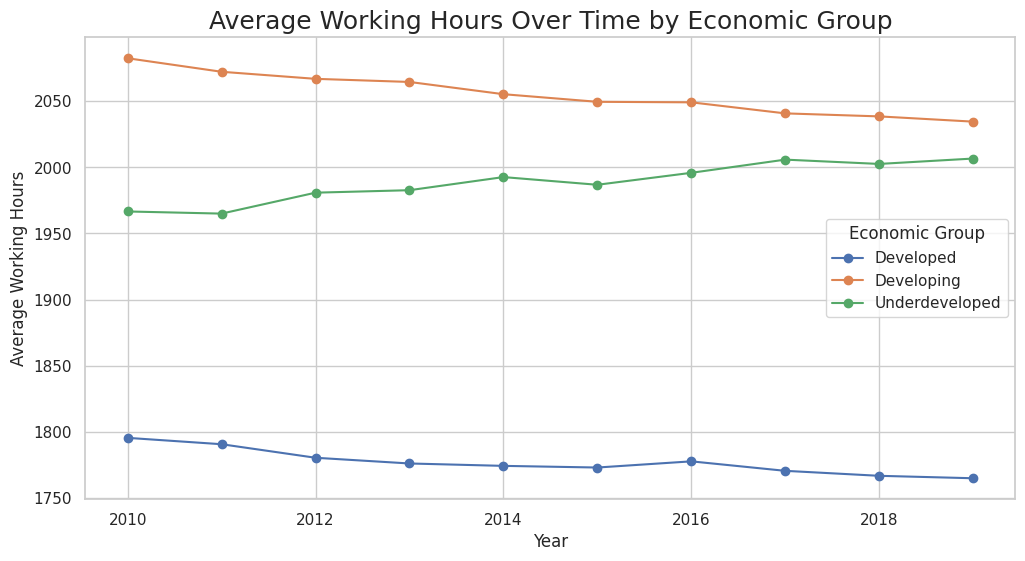

In [ ]:
grouped = final_df.groupby(['Year', 'Economic_Group'])['Working_hours_per_worker'].mean().reset_index()
plt.figure(figsize=(12, 6))
for group in grouped['Economic_Group'].unique():
    subset = grouped[grouped['Economic_Group'] == group]
    plt.plot(subset['Year'], subset['Working_hours_per_worker'], marker='o', label=group)
    plt.title('Average Working Hours Over Time by Economic Group', fontsize=18)
plt.xlabel('Year')
plt.ylabel('Average Working Hours')
plt.legend(title="Economic Group")

From the graph, we can observe that:
*   Developed countries consistently showed the lowest average working hours throughout the decade, with a relatively stable trend.
*   The underdeveloped group exhibited intermediate average working hours with more fluctuation compared to developed group. It experienced a rise by the end of the decase
*   Developing countries generally had the highest average working hours among three groups, although it gradually decreased and moved closer to the underdeveloped group.






In [ ]:
from scipy.stats import chi2_contingency

# Define the desired order for working hour categories
working_hours_order = ['high', 'medium', 'low']

# Convert the 'Working_hours_Category_2010_2019' column to a categorical type with the specified order
merged_df_processed_interpolated['Working_hours_Category_2010_2019'] = pd.Categorical(
    merged_df_processed_interpolated['Working_hours_Category_2010_2019'],
    categories=working_hours_order,
    ordered=True
)

# Create a contingency table
contingency_table = pd.crosstab(
    merged_df_processed_interpolated['Economic_Group'],
    merged_df_processed_interpolated['Working_hours_Category_2010_2019']
)

print("Contingency Table (Economic Group vs. Working Hours Category):")
display(contingency_table)

# Perform the Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square Statistic: {chi2}")
print(f"P-value: {p_value}")
print(f"Degrees of Freedom: {dof}")

# Interpret the results
if p_value < 0.05:
    print("Conclusion: There is a statistically significant association between economic groups and working hour categories.")
else:
    print("Conclusion: There is no statistically significant association between economic groups and working hour categories.")

Contingency Table (Economic Group vs. Working Hours Category):


Working_hours_Category_2010_2019,high,medium,low
Economic_Group,,,
Developed,40,90,200
Developing,270,200,90
Underdeveloped,80,80,80



Chi-square Statistic: 208.85302385302384
P-value: 4.689126444812835e-44
Degrees of Freedom: 4
Conclusion: There is a statistically significant association between economic groups and working hour categories.


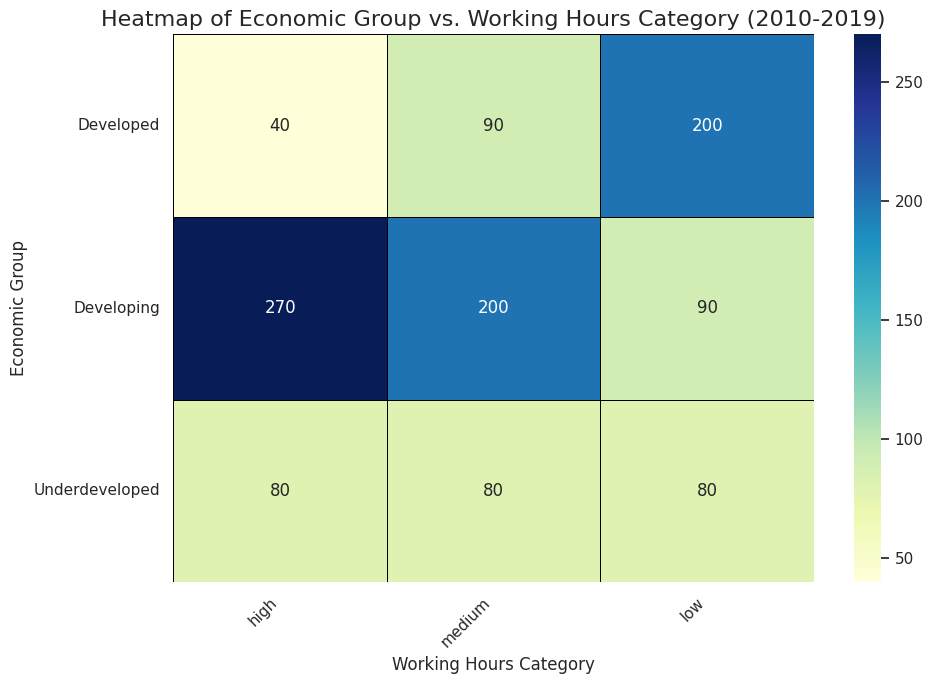

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(
    contingency_table,
    annot=True, # Show the counts in the cells
    fmt='d',    # Format annotations as integers
    cmap='YlGnBu', # Choose a color map
    linewidths=.5, # Add lines between cells
    linecolor='black'
)

plt.title('Heatmap of Economic Group vs. Working Hours Category (2010-2019)', fontsize=16)
plt.xlabel('Working Hours Category', fontsize=12)
plt.ylabel('Economic Group', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.tight_layout()
plt.show()

The Chi-square test revealed a highly statistically significant association between a country's economic group (Underdeveloped, Developing, Developed) and its working hours category (low, medium, high). With p-value < 0.05, this indicates that the distribution of working hours differs significantly across these economic classifications.

From the contingency table and heatmap, we can observe distinct patterns:

*   **Developed Countries:** Tend to have a higher proportion of countries in the 'low' working hours category, suggesting that more economically advanced nations generally work fewer hours annually.

*   **Developing Countries:** Show a concentration in the 'medium' and 'high' working hours categories, indicating that these countries often experience longer working hours.

*   **Underdeveloped Countries:** Are more evenly distributed across all working hour categories.

This association highlights that economic development is a crucial factor influencing national working hour patterns. Hence, in the next part, we will evaluate the relationship between well-being indicators and working hours with the consideration of economic contexts, that is, we will analyze well-being in each economic group.


### **Relationship between Working Hours and Well-being among Economic Groups**

Now, we will visualize the relation between working hour with mental health for each economic group of countries.

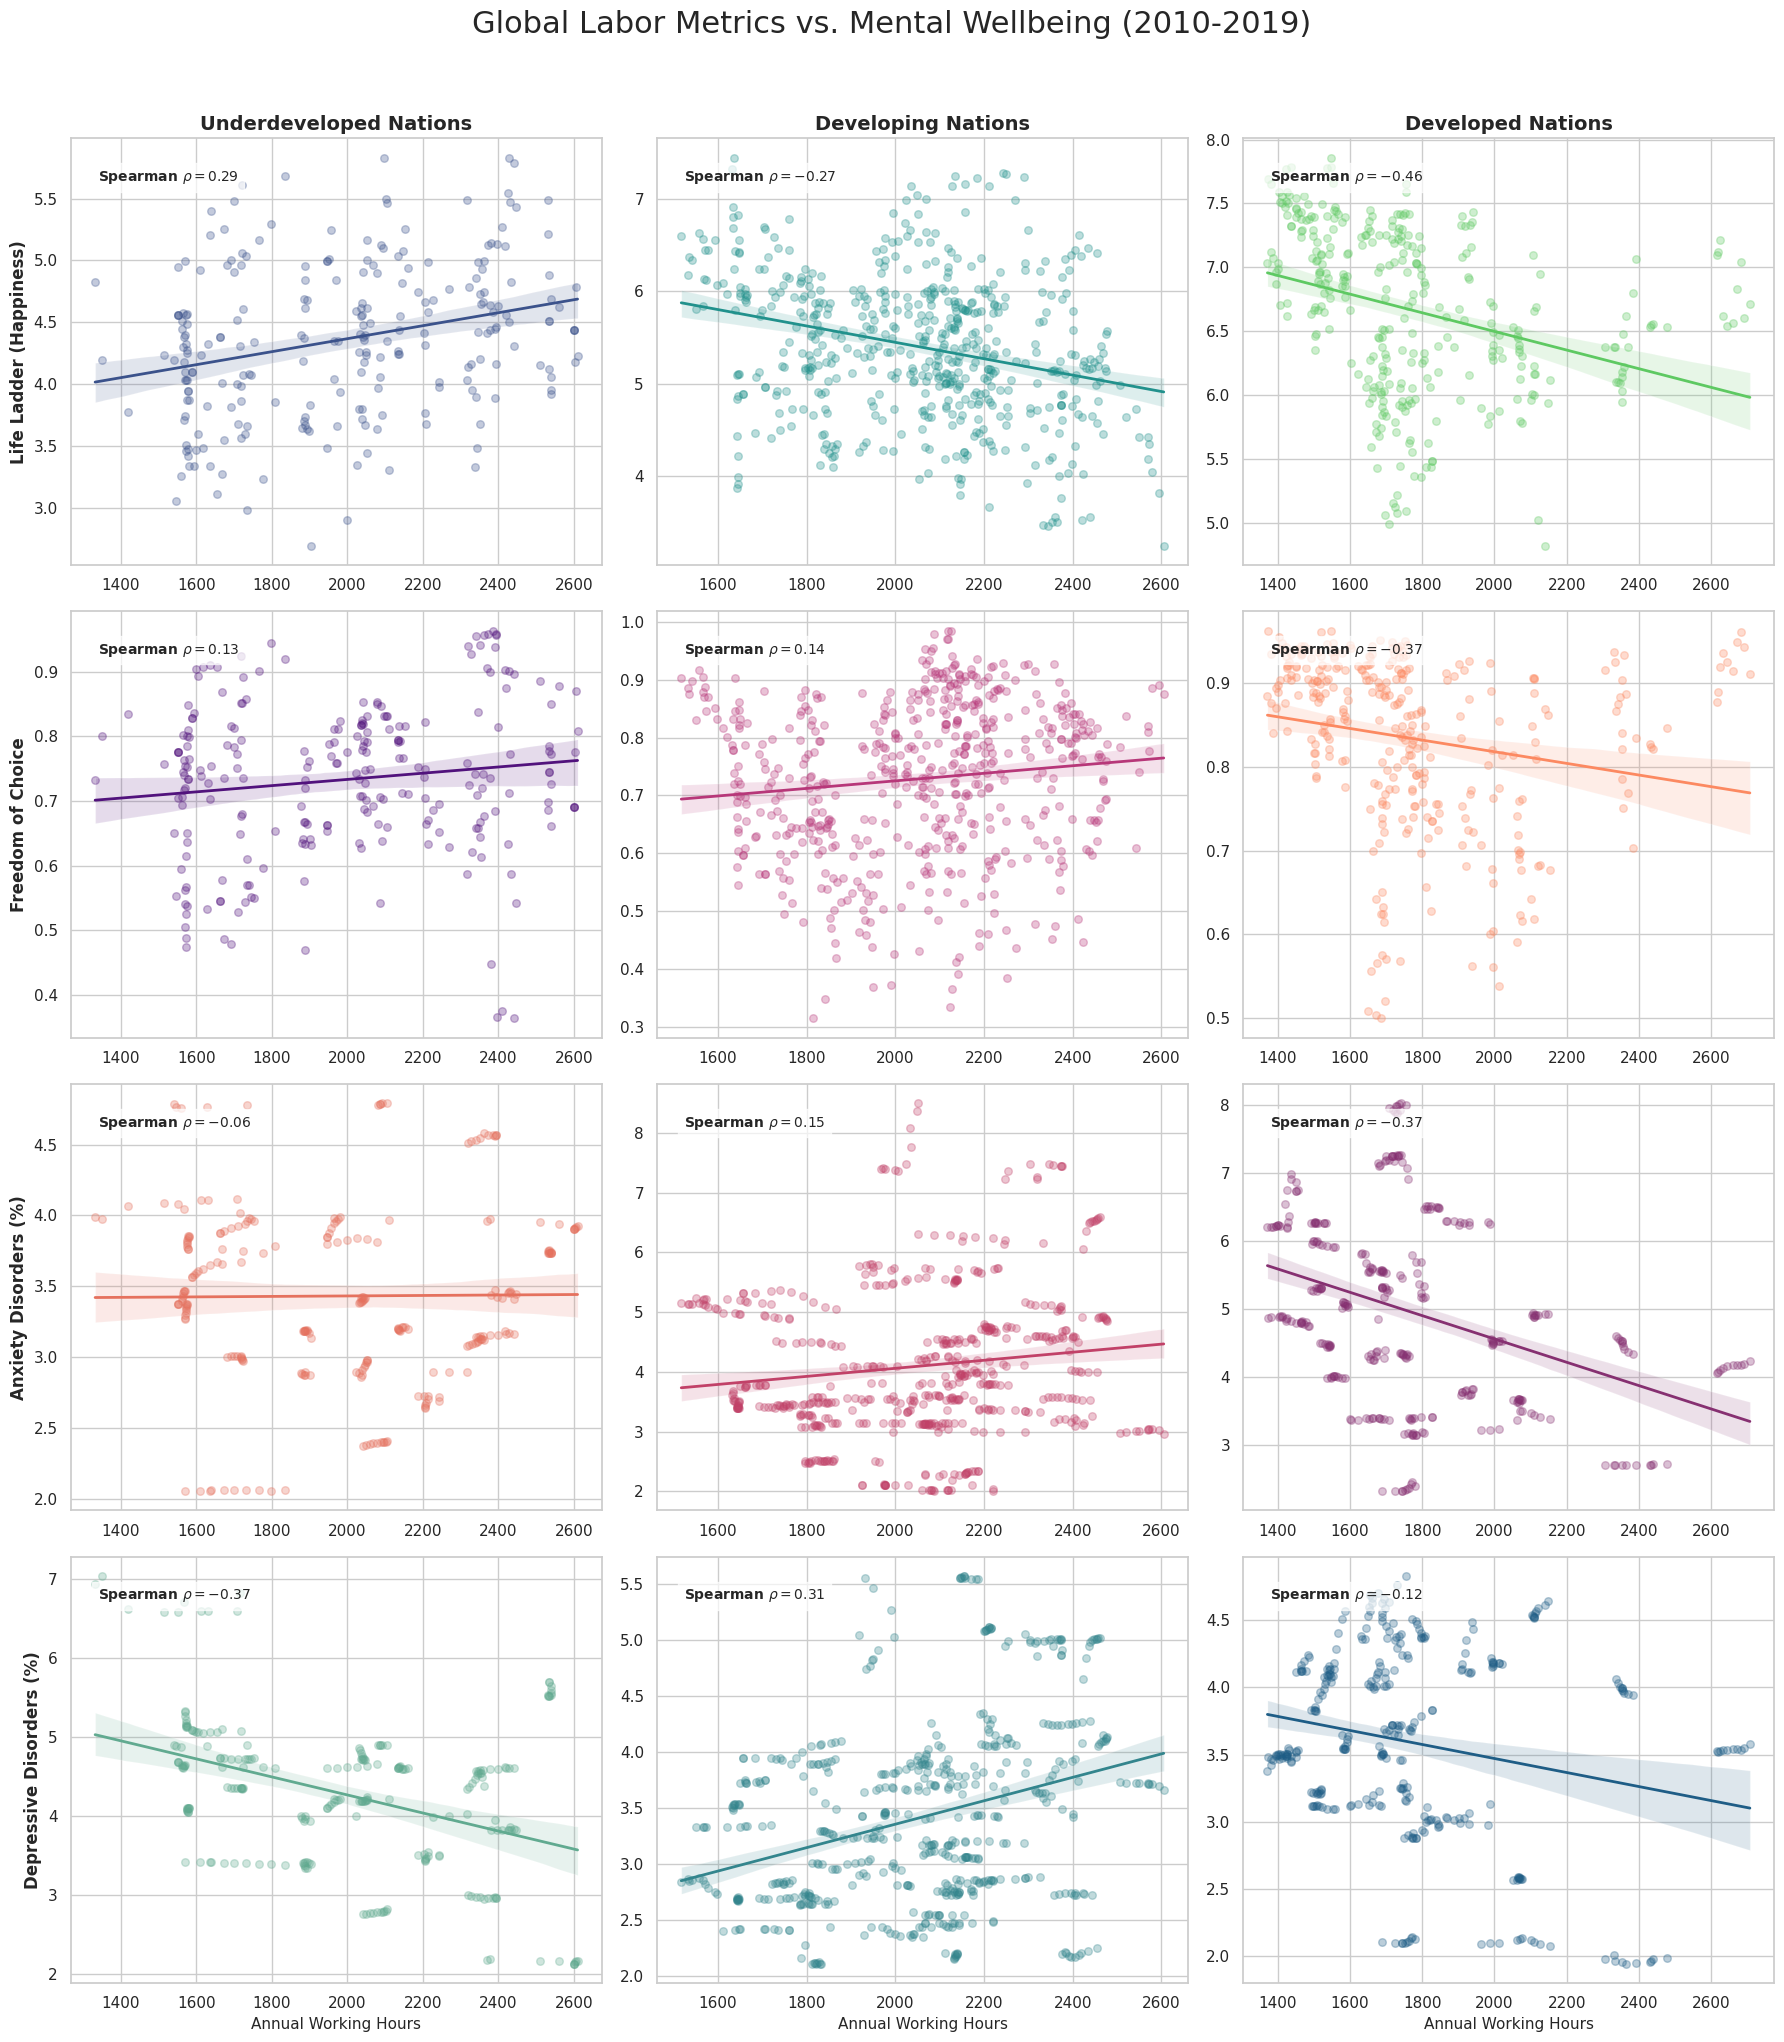

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Setup the figure and grid (4 rows, 3 columns)
# Rows: Happiness, Freedom, Anxiety, Depression
# Cols: Underdeveloped, Developing, Developed
metrics = [
    ('Life_Ladder', 'Life Ladder (Happiness)', 'viridis'),
    ('Freedom_To_Make_Life_Choices', 'Freedom of Choice', 'magma'),
    ('Anxiety_disorders', 'Anxiety Disorders (%)', 'flare'),
    ('Depressive_disorders', 'Depressive Disorders (%)', 'crest')
]
groups = ['Underdeveloped', 'Developing', 'Developed']

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20), sharex=False)
sns.set_theme(style="whitegrid")

# 2. Iterate through rows (metrics) and columns (economic groups)
for row_idx, (col_name, ylabel, palette_name) in enumerate(metrics):
    palette = sns.color_palette(palette_name, n_colors=3)

    for col_idx, group in enumerate(groups):
        ax = axes[row_idx, col_idx]
        subset = merged_df_processed_interpolated[merged_df_processed_interpolated['Economic_Group'] == group]

        # Plot regression and scatter
        sns.regplot(
            data=subset,
            x='Working_hours_per_worker',
            y=col_name,
            ax=ax,
            color=palette[col_idx],
            scatter_kws={'alpha': 0.3, 's': 30},
            line_kws={'lw': 2}
        )

        # Calculate Spearman Correlation
        clean_data = subset[['Working_hours_per_worker', col_name]].dropna()
        if len(clean_data) > 1:
            rho, p = stats.spearmanr(clean_data['Working_hours_per_worker'], clean_data[col_name])
            ax.text(.05, .9, f'Spearman $\\rho = {rho:.2f}$',
                    transform=ax.transAxes, fontsize=10,
                    fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

        # Formatting titles and labels
        if row_idx == 0:
            ax.set_title(f"{group} Nations", fontsize=14, fontweight='bold')

        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")

        if row_idx == 3:
            ax.set_xlabel("Annual Working Hours", fontsize=11)
        else:
            ax.set_xlabel("")

# 3. Final Adjustments
plt.suptitle('Global Labor Metrics vs. Mental Wellbeing (2010-2019)', fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig('merged_work_wellbeing_metrics.png', bbox_inches='tight')
plt.show()

These charts show Spearman correlation between well-being factors and working hour in each economic group. We can see clear trend in each graph with meaningful relationship. However, we still need to calculate p-value to determine whether the correlation is meaningful or not.

In [ ]:
import pandas as pd
import seaborn as sns
from scipy import stats

# 1. Define the features to analyze
features = [
    'Life_Ladder',
    'Freedom_To_Make_Life_Choices',
    'Anxiety_disorders',
    'Depressive_disorders'
]

# 2. Calculate Rho and P-Values
summary_data = []
for group in ['Underdeveloped', 'Developing', 'Developed']:
    group_data = merged_df_processed_interpolated[merged_df_processed_interpolated['Economic_Group'] == group]

    for feature in features:
        clean_pair = group_data[['Working_hours_per_worker', feature]].dropna()

        if len(clean_pair) > 1:
            rho, p_val = stats.spearmanr(clean_pair['Working_hours_per_worker'], clean_pair[feature])
            summary_data.append({
                'Economic_Group': group,
                'Feature': feature,
                'Spearman_Rho': rho,
                'P_Value': p_val
            })

# 3. Create the DataFrame and Pivot
summary_df = pd.DataFrame(summary_data)
final_summary = summary_df.pivot(index='Feature', columns='Economic_Group', values=['Spearman_Rho', 'P_Value'])

# 4. Create a "Better" Visualization using Pandas Styler
# This creates a heatmap effect within a table and keeps scientific notation
styled_table = final_summary.style.format({
    ('P_Value', 'Underdeveloped'): "{:.2e}",
    ('P_Value', 'Developing'): "{:.2e}",
    ('P_Value', 'Developed'): "{:.2e}",
    ('Spearman_Rho', 'Underdeveloped'): "{:.3f}",
    ('Spearman_Rho', 'Developing'): "{:.3f}",
    ('Spearman_Rho', 'Developed'): "{:.3f}"
}).background_gradient(
    cmap='RdYlGn',  # Red (Negative) to Green (Positive)
    subset=pd.IndexSlice[:, (['Spearman_Rho'], slice(None))],
    axis=None,
    vmin=-1, vmax=1
).set_caption("Spearman Correlation (Rho) and P-Value by Economic Group")

# Display the styled table
display(styled_table)

This shows that only result of anxiety_disorders in underdeveloped countries is not meaningful. Looking at the rest, we can see some relationships:

* In Developed countries, increaseing in working hours tend to highly reduce both Life_ladder, Freedom_To_Make_Life_Choices and Anxiety_disorders. The Depressive_disorders also have negative correlation, but a bit smaller.

* In Developing countries, increasing in working hours lead to increasing in mental issues and Freedom_To_Make_Life_Choices, but reducing in Life_Ladder.

* In Underdeveloped countries, strong negative correlation in Depressive_disorders and positive correlation in happniess are witnessed.

From the above, we can see what happen to well-being if people work more, in each economic status.

# **Presentation of Main Results (Share)**

### 1. Stakeholder: Policymakers, Employers and Workers
This analysis provides insights for policymakers (government officials, public health strategists) shaping labor laws and social welfare, employers managing work environments and employee well-being, and workers advocating for improved working conditions. These groups can be equipped with evidence-based conclusions to inform decisions on working hours, well-being, and productivity.

### 2. Visualization/Summary

Below is a heatmap summarizing the Spearman correlation coefficients between annual working hours and various well-being indicators, broken down by economic group. This visualization clearly illustrates the strength and direction of these relationships across different national economic contexts.

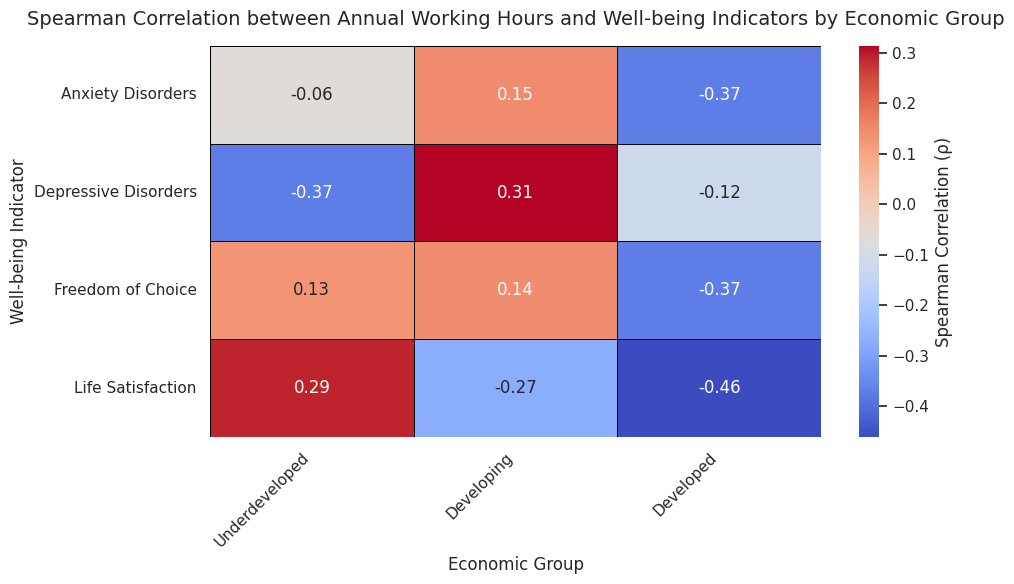

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming final_summary DataFrame from cell iW33htPQL98k is available
# Re-create final_summary if not directly available for execution
# This block ensures that if the notebook is run out of order,
# the final_summary DataFrame is recreated for the heatmap.
if 'final_summary' not in locals():
    summary_data = []
    features = [
        'Life_Ladder',
        'Freedom_To_Make_Life_Choices',
        'Anxiety_disorders',
        'Depressive_disorders'
    ]
    for group in ['Underdeveloped', 'Developing', 'Developed']:
        group_data = final_df[final_df['Economic_Group'] == group]
        for feature in features:
            clean_pair = group_data[['Working_hours_per_worker', feature]].dropna()
            if len(clean_pair) > 1:
                rho, p_val = stats.spearmanr(clean_pair['Working_hours_per_worker'], clean_pair[feature])
                summary_data.append({
                    'Economic_Group': group,
                    'Feature': feature,
                    'Spearman_Rho': rho,
                    'P_Value': p_val
                })
    summary_df = pd.DataFrame(summary_data)
    final_summary = summary_df.pivot(index='Feature', columns='Economic_Group', values=['Spearman_Rho', 'P_Value'])

# Extract only the Spearman_Rho values for the heatmap
rho_pivot = final_summary['Spearman_Rho']

# Reorder columns for better readability
column_order = ['Underdeveloped', 'Developing', 'Developed']
rho_pivot = rho_pivot[column_order]

# Rename features for display
rho_pivot = rho_pivot.rename(index={
    'Life_Ladder': 'Life Satisfaction',
    'Freedom_To_Make_Life_Choices': 'Freedom of Choice',
    'Anxiety_disorders': 'Anxiety Disorders',
    'Depressive_disorders': 'Depressive Disorders'
})

plt.figure(figsize=(10, 6))
sns.heatmap(
    rho_pivot,
    annot=True,
    cmap='coolwarm', # Choose a diverging colormap to show positive/negative correlations
    fmt=".2f", # Format annotations to two decimal places
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Spearman Correlation (ρ)'}
)

plt.title('Spearman Correlation between Annual Working Hours and Well-being Indicators by Economic Group', fontsize=14, pad=15)
plt.xlabel('Economic Group', fontsize=12)
plt.ylabel('Well-being Indicator', fontsize=12)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3. Short Narrative of Final Result to Stakeholders
**Overall Trend**: Generally, longer working hours tend to be associated with lower life satisfaction and freedom of choice, and higher percentage of anxiety and depressive disorders. However, the strength of these relationships varies significantly by a country's economic status.

* **Underdeveloped countries**: Longer working hours are associated with lower depression, slightly higher life satisfaction, and small positive links to freedom of choice, with almost no relation to anxiety. In lower-income contexts, working more may improve financial stability and basic living conditions, which can reduce depression and slightly enhance life satisfaction and perceived autonomy.

* **Developing countries:** Longer hours are linked to higher depression and anxiety, lower life satisfaction, but a small increase in freedom of choice. Economic transition and job pressure may lead to overwork and stress, worsening mental health, even though individuals may feel they are gaining more opportunities or control.

* **Developed countries:** Longer working hours are associated with lower anxiety and depression, but also lower life satisfaction and freedom of choice.
Explanation: While structured employment and financial security may help reduce mental health disorders, longer hours can still harm overall life satisfaction and perceived autonomy due to work-life imbalance and reduced leisure time.

**Implications for Policy**: Our findings underscore that 'one-size-fits-all' labor policies may not be effective. In developed nations, policies aimed at reducing working hours could have a tangible positive impact on mental health and overall happiness. For developing and underdeveloped countries, while working hours are a factor, a more holistic approach addressing economic stability, access to healthcare, and social support systems might be necessary. We recommend further research within specific economic groups with more features to refine these insights and guide precise policy formulation.

# **Possible Actions Based On Results (Act)**


In developed countries, when working hours icnrease, the freedom to make life choices as well as happiness level decreased. Therefore, policy makers as well as employers in those countries should promote work-life balances law, such as flexible work or paid leave. They should also promote autonomy and freedom-suporting policies.

Meanwhile, in developing countries, increasing working hours can lead to increase in depressive disorders as well as decrease in happiness level. Therefore, employers should offer mental health benefits, such as therapy coverage or counselling, at workplace. They can also encourage employee autonomy by providing flexible working hours or remote work to avoid burn out among workers.

In contrast, in underdeveloped countries, when working hours increases, people experience higher level of happiness as well as lower level of anxiety or depression. This can be explained by the fact that when working hours increases, residents in those countries can achieve more financial stability, increasing both their well-being and life quality. Therefore, policy makers in those countries should focus on job security for residents first and still ensure offering mental health programs for them.





# **Final Reflection**

## **Consideration of Data Ethics**

Given the avaiblable data, the results apply for both developed, developing and underdeveloped countries, showing no bias between countries. However, mental health indicators such as anxiety and depression can cause stigmatization between countries or populations, and there is a risk of labelling countries as mental health unhealthy or high depression nations. Therefore, for ethical requirement, we always present results in non-stigmatizing context.

## **Consideration of Data Privacy and Data Security**

Given the avaiblable data, the results apply for both developed, developing and underdeveloped countries, showing no bias between countries. However, mental health indicators such as anxiety and depression can cause stigmatization between countries or populations, and there is a risk of labelling countries as mental health unhealthy or high depression nations. Therefore, for ethical requirement, we always present results in non-stigmatizing context.

# **REFERENCES**

Ezekekwu, E., Johnson, C., Karimi, S., Lorenz, D., & Antimisiaris, D.(2024). A longitudinal analysis of long working hours and the onset of psychological distress. *Journal of Occupational and Environmental Medicine,* 67(1), 11-18. https://doi.org/10.1097/jom.0000000000003231

Ahn,S.(2017). Working hours and depresisve symptoms over 7 years: evidence from a Korean panel study. *International Archieves of Occupational and Environmental Health,* 91(3), 273-283. https://doi.org/10.1007/s00420-017-1278-z

Cho, S., Ki, M., Kim, K., Ju, Y., Paek, D., & Lee, W.(2015). Working hours and self-rated health over 7 years: gender differences in a Korean lonitudinal study. *BMC Public Health,* 15(1), 1287. https://doi.org/10.1186/s12889-015-2641-1